# Config

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
from matplotlib.lines import Line2D

BASE = Path("C:/Users/jagui/Desktop/BThesis")
FONT = "Palatino Linotype"
FONT_SIZE = 14
COLOR_MAIN = "#e8e8e8d6"
COLOR_SUB  = "#e6e6e6"
WIDTH_MAIN = 1
WIDTH_SUB  = 0.8

# PART 1: BASELINE ANALYSIS

## E2E Fixed-Chunk Baseline 

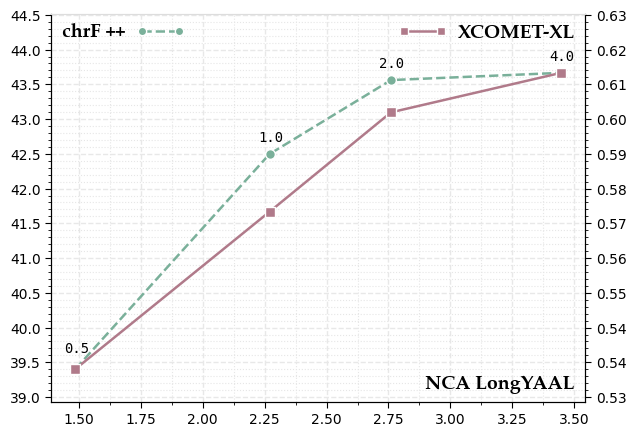

In [2]:
df = pd.read_csv(BASE / "experiments/baselines_trades/fixed/results_fixed.csv")
df = df[df["jsonl_file"] != "fixed_step8.0"]

def step_label(name):
    return name.replace("fixed_step", "")

df["step_val"] = df["jsonl_file"].apply(step_label)
df = df.sort_values("long_yaal_nca")

fig, ax1 = plt.subplots(1, 1, figsize=(7, 5))
ax2 = ax1.twinx()

COLOR_1 = "#7ab09a"  # verde azulado apagado
COLOR_2 = "#b07a8a"  # rosa terroso apagado

# ── Líneas ─────────────────────────────────────────────────────────────────
ax1.plot(df["long_yaal_nca"], df["chrf_pp"],
         color=COLOR_1, linewidth=1.8,
         marker="o", markersize=7,
         markerfacecolor=COLOR_1,
         markeredgecolor="white",
         markeredgewidth=1,
         linestyle="--",
         zorder=3)

ax2.plot(df["long_yaal_nca"], df["comet_xl"],
         color=COLOR_2, linewidth=1.8,
         marker="s", markersize=7,
         markerfacecolor=COLOR_2,
         markeredgecolor="white",
         markeredgewidth=1,
         linestyle="-",
         zorder=3)

# ── Límites con padding ────────────────────────────────────────────────────
PAD_BOT = 0.11
PAD_TOP = 0.20

for ax, col in [(ax1, "chrf_pp"), (ax2, "comet_xl")]:
    ymin, ymax = df[col].min(), df[col].max()
    yr = ymax - ymin
    ax.set_ylim(ymin - yr * PAD_BOT, ymax + yr * PAD_TOP)

# ── Sincronizar ticks ──────────────────────────────────────────────────────
y1_min, y1_max = ax1.get_ylim()
y2_min, y2_max = ax2.get_ylim()

ax1_ticks = np.arange(np.ceil(y1_min * 2) / 2, y1_max, 0.5)
ax1.set_yticks(ax1_ticks)

def map_to_ax2(v):
    t = (v - y1_min) / (y1_max - y1_min)
    return y2_min + t * (y2_max - y2_min)

ax2_ticks = [map_to_ax2(v) for v in ax1_ticks]
ax2.set_yticks(ax2_ticks)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2f}"))

ax1.yaxis.set_minor_locator(AutoMinorLocator(5))
ax2.yaxis.set_minor_locator(AutoMinorLocator(5))
ax1.xaxis.set_minor_locator(AutoMinorLocator(2))

# ── Desactivar ticks superiores ────────────────────────────────────────────
ax1.tick_params(top=False, which="both")
ax2.tick_params(top=False, which="both")

# ── Estilo spines ──────────────────────────────────────────────────────────
for ax in [ax1, ax2]:
    ax.set_facecolor("white")
    ax.tick_params(which="major", colors="#000000", length=4, labelsize=10)
    ax.tick_params(which="minor", colors="#000000", length=2, labelsize=0)
    ax.tick_params(axis="y", colors="#000000")
    ax.tick_params(axis="x", colors="#000000")
    ax.spines["top"].set_color("#dddddd")
    ax.spines["bottom"].set_color("black")
    ax.spines["left"].set_color("black")
    ax.spines["right"].set_color("black")

ax1.grid(which="major", color=COLOR_MAIN, linewidth=WIDTH_MAIN, linestyle="--", zorder=0)
ax1.grid(which="minor", color=COLOR_SUB,  linewidth=WIDTH_SUB,  linestyle=":",  zorder=0)

# ── Anotaciones de step ────────────────────────────────────────────────────
offset1 = (ax1.get_ylim()[1] - ax1.get_ylim()[0]) * 0.015

texts = []
for _, row in df.iterrows():
    comet_in_ax1 = y1_min + (row["comet_xl"] - y2_min) / (y2_max - y2_min) * (y1_max - y1_min)
    y_anchor = max(row["chrf_pp"], comet_in_ax1)
    extra = 1.8 if row["step_val"] == "0.5" else 1.0
    t = ax1.text(row["long_yaal_nca"], y_anchor + offset1 * extra,
                 row["step_val"],
                 fontsize=10, color="#000000", fontfamily="monospace",
                 ha="center", va="bottom")
    texts.append(t)

adjust_text(texts, ax=ax1,
            expand_points=(1.2, 1.2),
            expand_text=(1, 1),
            force_text=2, force_points=2,
            only_move={"text": "y", "points": "y"})

# ── Labels y leyendas ──────────────────────────────────────────────────────
ax1.set_xlabel("")
ax1.set_ylabel("")
ax2.set_ylabel("")

LEGEND_Y   = 0.95
LEGEND_LEN = 0.07
GAP        = 0.02
TXT_W1     = 0.13
TXT_W2     = 0.23

ax1.text(0.02, LEGEND_Y, "chrF ++",
         transform=ax1.transAxes,
         fontsize=FONT_SIZE, fontfamily=FONT, fontweight="bold",
         ha="left", va="center", color="#000000", zorder=5)
ax1.plot([0.02 + TXT_W1 + GAP, 0.02 + TXT_W1 + GAP + LEGEND_LEN],
         [LEGEND_Y + 0.005, LEGEND_Y + 0.005],
         color=COLOR_1, linewidth=1.8, linestyle="--",
         marker="o", markersize=6,
         markerfacecolor=COLOR_1, markeredgecolor="white", markeredgewidth=1,
         transform=ax1.transAxes, zorder=5, clip_on=False)

ax1.text(0.98, LEGEND_Y, "XCOMET-XL",
         transform=ax1.transAxes,
         fontsize=FONT_SIZE, fontfamily=FONT, fontweight="bold",
         ha="right", va="center", color="#000000", zorder=5)
ax1.plot([0.98 - TXT_W2 - GAP - LEGEND_LEN, 0.98 - TXT_W2 - GAP],
         [LEGEND_Y + 0.005, LEGEND_Y + 0.005],
         color=COLOR_2, linewidth=1.8, linestyle="-",
         marker="s", markersize=6,
         markerfacecolor=COLOR_2, markeredgecolor="white", markeredgewidth=1,
         transform=ax1.transAxes, zorder=5, clip_on=False)

ax1.text(0.98, 0.02, "NCA LongYAAL",
         transform=ax1.transAxes,
         fontsize=FONT_SIZE, fontfamily=FONT, fontweight="bold",
         ha="right", va="bottom", color="#000000", zorder=5)

# ── Guardar ────────────────────────────────────────────────────────────────
fig.patch.set_facecolor("white")
plt.tight_layout(pad=3)

out_eps = BASE / "eps/experiments/fixed_plot.eps"
out = BASE / "experiments/baselines_trades/fixed/fixed_plot"
plt.savefig(out.with_suffix(".png"), dpi=550, bbox_inches="tight", facecolor="white")
plt.savefig(out_eps, bbox_inches="tight", facecolor="white")
plt.show()

## E2E VAD-Driven Baseline

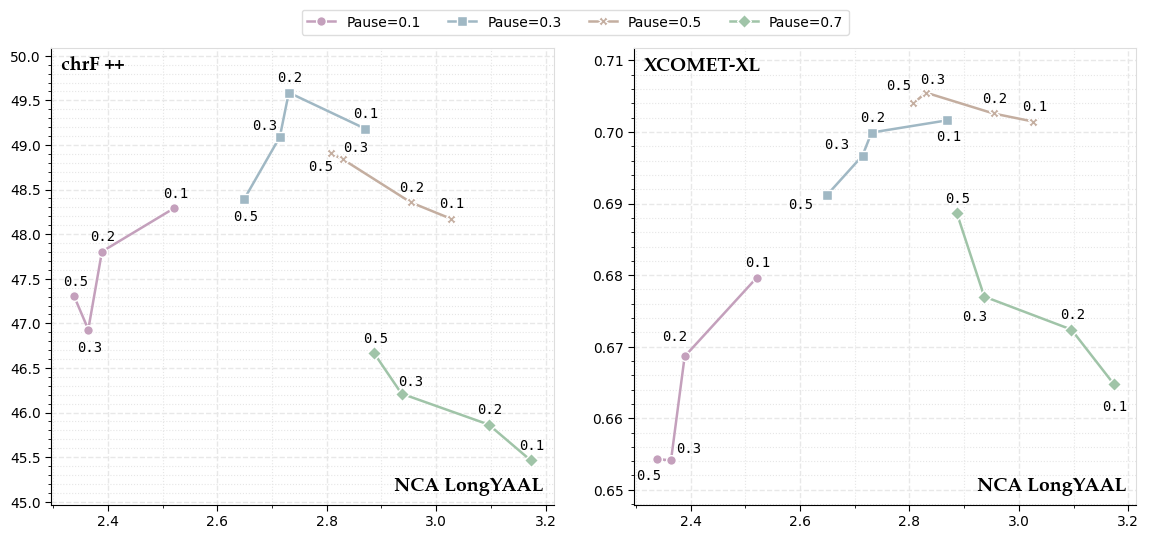

In [3]:
df = pd.read_csv(BASE / "experiments/baselines_trades/vad/results_vad.csv")

def parse_name(name):
    parts = name.split("_")
    pause = float(parts[1].replace("pause", ""))
    thr   = float(parts[2].replace("thr", ""))
    return pause, thr

df[["pause", "thr"]] = df["jsonl_file"].apply(lambda x: pd.Series(parse_name(x)))
df = df[df["pause"] < 1]
df = df[df["thr"] < 0.75]
df = df.sort_values(["pause", "thr"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

PAUSE_COLORS = {
    0.1: "#c4a0bc",
    0.3: "#a0b8c4",
    0.5: "#c4aea0",
    0.7: "#a0c4a8",
    1.0: "#c4c4a0",
}

PAUSE_MARKERS = {
    0.1: "o",
    0.3: "s",
    0.5: "X",
    0.7: "D",
    1.0: "^",
}

configs = [
    ("long_yaal_nca", "NCA LongYAAL", "chrf_pp",  "chrF ++",   0.5,  0.1),
    ("long_yaal_nca", "NCA LongYAAL", "comet_xl", "XCOMET-XL", 0.01, 0.002),
]

MANUAL_ADJUST = {
    (0.1, 0.3): (0.0,   -2.5),
    (0.3, 0.5): (0.0,   -2.5),
    (0.3, 0.3): (-0.03, 0),
    (0.5, 0.3): (0.02,  0.01),
    (0.5, 0.5): (-0.02,   -1.0),
    (0.7, 0.3): (0.015,   0.15),
}

MANUAL_ADJUST_COMET = {
    (0.1, 0.5): (-0.03, -2),    # bajar más y a la izq
    (0.1, 0.3): (0.03,   0.3),    # más a la derecha
    (0.1, 0.2): (-0.02,    2.5),    # subir un poco más
    (0.3, 0.5): (-0.05,  -0.000001),    # izq un pelín
    (0.3, 0.3): (-0.05,   0),    # más a la izquierda
    (0.3, 0.1): (0.0,   -2.0),    # bajar un pelín
    (0.5, 0.5): (-0.03,  2.0),    # arriba izq un pelín
    (0.5, 0.3): (0.01,   0.5),    # no bajar tanto
    (0.7, 0.3): (-0.02, -3.0),    # bajar mucho y un poco a la izq
    (0.7, 0.1): (0.0,   -4.0),    # bajar mucho
}

handle_map = {}

for idx, (xcol, xlabel, ycol, ylabel, tick_step, minor_step) in enumerate(configs):
    ax = axes[idx]

    ax.set_facecolor("white")
    ax.grid(which="major", color=COLOR_MAIN, linewidth=WIDTH_MAIN, linestyle="--", zorder=0)
    ax.grid(which="minor", color=COLOR_SUB, linewidth=WIDTH_SUB, linestyle=":", zorder=0)
    ax.spines["bottom"].set_color("black")
    ax.spines["left"].set_color("black")
    ax.spines["top"].set_color("#dddddd")
    ax.spines["right"].set_color("#dddddd")
    ax.tick_params(which="major", colors="#000000", length=4, labelsize=10)
    ax.tick_params(which="minor", colors="#000000", length=2, labelsize=0)
    ax.tick_params(axis="y", colors="#000000")
    ax.tick_params(axis="x", colors="#000000")
    ax.tick_params(top=False, which="both")

    for pause, group in df.groupby("pause"):
        color  = PAUSE_COLORS[pause]
        marker = PAUSE_MARKERS[pause]
        line, = ax.plot(group[xcol], group[ycol],
                        color=color, linewidth=1.8,
                        marker=marker, markersize=7,
                        markerfacecolor=color,
                        markeredgecolor="white",
                        markeredgewidth=1,
                        zorder=3)
        if idx == 0:
            handle_map[pause] = line

    ymin, ymax = df[ycol].min(), df[ycol].max()
    yrange_data = ymax - ymin
    PAD = 0.12
    ax.set_ylim(ymin - yrange_data * PAD, ymax + yrange_data * PAD)

    ax.yaxis.set_major_locator(MultipleLocator(tick_step))
    ax.yaxis.set_minor_locator(MultipleLocator(minor_step))
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))

    offset = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.007

    texts = []
    for pause, group in df.groupby("pause"):
        for _, row in group.iterrows():
            key = (pause, row["thr"])
            flip = (pause == 0.1 and row["thr"] == 0.3) or \
                   (pause == 0.3 and row["thr"] in (0.3, 0.5))
            sign = -1 if (ycol == "chrf_pp" and flip) else 1

            if key in MANUAL_ADJUST and ycol == "chrf_pp":
                x_off, y_mult = MANUAL_ADJUST[key]
                y_pos = row[ycol] + y_mult * offset
                va = "top" if y_mult < 0 else "bottom"
            elif key in MANUAL_ADJUST_COMET and ycol == "comet_xl":
                x_off, y_mult = MANUAL_ADJUST_COMET[key]
                y_pos = row[ycol] + y_mult * offset
                va = "top" if y_mult < 0 else "bottom"
            else:
                x_off = 0.0
                y_pos = row[ycol] + sign * offset
                va = "top" if sign == -1 else "bottom"

            t = ax.text(row[xcol] + x_off, y_pos,
                        f"{row['thr']}",
                        fontsize=10, color="#000000", fontfamily="monospace",
                        ha="center", va=va)
            texts.append(t)

    adjust_text(texts, ax=ax,
                expand_points=(3, 3),
                expand_text=(3, 3),
                force_text=3, force_points=3,
                only_move={"text": "xy", "points": "xy"})

    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.text(0.98, 0.02, xlabel,
            transform=ax.transAxes,
            fontsize=FONT_SIZE, fontfamily=FONT, fontweight="bold",
            ha="right", va="bottom", color="#000000", zorder=5)

    ax.text(0.02, 0.98, ylabel,
            transform=ax.transAxes,
            fontsize=FONT_SIZE, fontfamily=FONT, fontweight="bold",
            ha="left", va="top", color="#000000", zorder=5)

# ── Leyenda ────────────────────────────────────────────────────────────────
handles       = [handle_map[p] for p in sorted(handle_map)]
legend_labels = [f"Pause={p}" for p in sorted(handle_map)]

fig.legend(handles, legend_labels,
           loc="upper center",
           bbox_to_anchor=(0.5, 1.02),
           ncol=5,
           fontsize=10,
           frameon=True,
           framealpha=0.9,
           edgecolor="#dddddd")

fig.patch.set_facecolor("white")
plt.tight_layout(pad=2.5)

out_eps = BASE / "eps/experiments/vad_plot.eps"
out = BASE / "experiments/baselines_trades/vad/vad_plot"
plt.savefig(out.with_suffix(".png"), dpi=550, bbox_inches="tight", facecolor="white")
legend = fig.legends[0]
legend.get_frame().set_alpha(1.0)
plt.savefig(out_eps, bbox_inches="tight", facecolor="white")
plt.show()

## Cascade LLM-Based Baseline

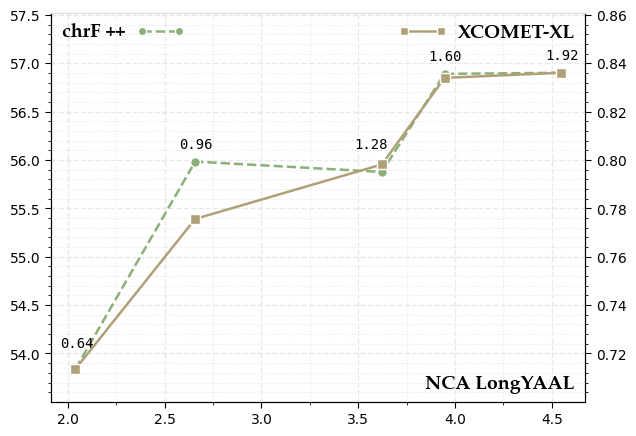

In [4]:
df = pd.read_csv(BASE / "experiments/baselines_trades/cascade_2026/results_cascade_2026.csv")

def seg_label(name):
    seg = name.split("seg")[1]
    return float(seg) / 1000

df["seg_val"] = df["jsonl_file"].apply(seg_label)
df = df.sort_values("long_yaal_nca")

fig, ax1 = plt.subplots(1, 1, figsize=(7, 5))
ax2 = ax1.twinx()

COLOR_1 = "#8ab078"  # gris azulado más oscuro
COLOR_2 = "#b0a078"  # dorado apagado más oscuro

# ── Líneas ─────────────────────────────────────────────────────────────────
ax1.plot(df["long_yaal_nca"], df["chrf_pp"],
         color=COLOR_1, linewidth=1.8,
         marker="o", markersize=7,
         markerfacecolor=COLOR_1,
         markeredgecolor="white",
         markeredgewidth=1,
         linestyle="--",
         zorder=3)

ax2.plot(df["long_yaal_nca"], df["comet_xl"],
         color=COLOR_2, linewidth=1.8,
         marker="s", markersize=7,
         markerfacecolor=COLOR_2,
         markeredgecolor="white",
         markeredgewidth=1,
         linestyle="-",
         zorder=3)

# ── Límites con padding ────────────────────────────────────────────────────
PAD_BOT = 0.11
PAD_TOP = 0.20

for ax, col in [(ax1, "chrf_pp"), (ax2, "comet_xl")]:
    ymin, ymax = df[col].min(), df[col].max()
    yr = ymax - ymin
    ax.set_ylim(ymin - yr * PAD_BOT, ymax + yr * PAD_TOP)

# ── Sincronizar ticks ──────────────────────────────────────────────────────
y1_min, y1_max = ax1.get_ylim()
y2_min, y2_max = ax2.get_ylim()

ax1_ticks = np.arange(np.ceil(y1_min * 2) / 2, y1_max, 0.5)
ax1.set_yticks(ax1_ticks)

def map_to_ax2(v):
    t = (v - y1_min) / (y1_max - y1_min)
    return y2_min + t * (y2_max - y2_min)

ax2_ticks = [map_to_ax2(v) for v in ax1_ticks]
ax2.set_yticks(ax2_ticks)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2f}"))

ax1.yaxis.set_minor_locator(AutoMinorLocator(5))
ax2.yaxis.set_minor_locator(AutoMinorLocator(5))
ax1.xaxis.set_minor_locator(AutoMinorLocator(2))

# ── Desactivar ticks superiores ────────────────────────────────────────────
ax1.tick_params(top=False, which="both")
ax2.tick_params(top=False, which="both")

# ── Estilo spines ──────────────────────────────────────────────────────────
for ax in [ax1, ax2]:
    ax.set_facecolor("white")
    ax.tick_params(which="major", colors="#000000", length=4, labelsize=10)
    ax.tick_params(which="minor", colors="#000000", length=2, labelsize=0)
    ax.tick_params(axis="y", colors="#000000")
    ax.tick_params(axis="x", colors="#000000")
    ax.spines["top"].set_color("#dddddd")
    ax.spines["bottom"].set_color("black")
    ax.spines["left"].set_color("black")
    ax.spines["right"].set_color("black")

ax1.grid(which="major", color=COLOR_MAIN, linewidth=WIDTH_MAIN, linestyle="--", zorder=0)
ax1.grid(which="minor", color=COLOR_SUB,  linewidth=WIDTH_SUB,  linestyle=":",  zorder=0)

# ── Anotaciones de step ────────────────────────────────────────────────────
offset1 = (ax1.get_ylim()[1] - ax1.get_ylim()[0]) * 0.02

texts = []
for _, row in df.iterrows():
    comet_in_ax1 = y1_min + (row["comet_xl"] - y2_min) / (y2_max - y2_min) * (y1_max - y1_min)
    y_anchor = max(row["chrf_pp"], comet_in_ax1)
    extra = 1.2 if abs(row["seg_val"] - 1.28) < 1e-9 else 0.9
    extra = 2 if abs(row["seg_val"] - 0.64) < 1e-9 else extra
    x_offset = -0.06 if abs(row["seg_val"] - 1.28) < 1e-9 else 0.0
    t = ax1.text(row["long_yaal_nca"] + x_offset, y_anchor + (offset1 * extra),
                 f"{row['seg_val']:.2f}",
                 fontsize=10, color="#000000", fontfamily="monospace",
                 ha="center", va="bottom")
    texts.append(t)

adjust_text(texts, ax=ax1,
            expand_points=(1.2, 1.2),
            expand_text=(1, 1),
            force_text=2, force_points=2,
            only_move={"text": "y", "points": "y"})

# ── Labels y leyendas ──────────────────────────────────────────────────────
ax1.set_xlabel("")
ax1.set_ylabel("")
ax2.set_ylabel("")

LEGEND_Y   = 0.95
LEGEND_LEN = 0.07
GAP        = 0.02
TXT_W1     = 0.13
TXT_W2     = 0.23

ax1.text(0.02, LEGEND_Y, "chrF ++",
         transform=ax1.transAxes,
         fontsize=FONT_SIZE, fontfamily=FONT, fontweight="bold",
         ha="left", va="center", color="#000000", zorder=5)
ax1.plot([0.02 + TXT_W1 + GAP, 0.02 + TXT_W1 + GAP + LEGEND_LEN],
         [LEGEND_Y + 0.005, LEGEND_Y + 0.005],
         color=COLOR_1, linewidth=1.8, linestyle="--",
         marker="o", markersize=6,
         markerfacecolor=COLOR_1, markeredgecolor="white", markeredgewidth=1,
         transform=ax1.transAxes, zorder=5, clip_on=False)

ax1.text(0.98, LEGEND_Y, "XCOMET-XL",
         transform=ax1.transAxes,
         fontsize=FONT_SIZE, fontfamily=FONT, fontweight="bold",
         ha="right", va="center", color="#000000", zorder=5)
ax1.plot([0.98 - TXT_W2 - GAP - LEGEND_LEN, 0.98 - TXT_W2 - GAP],
         [LEGEND_Y + 0.005, LEGEND_Y + 0.005],
         color=COLOR_2, linewidth=1.8, linestyle="-",
         marker="s", markersize=6,
         markerfacecolor=COLOR_2, markeredgecolor="white", markeredgewidth=1,
         transform=ax1.transAxes, zorder=5, clip_on=False)

ax1.text(0.98, 0.02, "NCA LongYAAL",
         transform=ax1.transAxes,
         fontsize=FONT_SIZE, fontfamily=FONT, fontweight="bold",
         ha="right", va="bottom", color="#000000", zorder=5)

# ── Guardar ────────────────────────────────────────────────────────────────
fig.patch.set_facecolor("white")
plt.tight_layout(pad=3)

out_eps = BASE / "eps/experiments/cascade_2026_plot.eps"
out = BASE / "experiments/baselines_trades/cascade_2026/cascade_2026_plot"
plt.savefig(out.with_suffix(".png"), dpi=550, bbox_inches="tight", facecolor="white")
plt.savefig(out_eps, bbox_inches="tight", facecolor="white")
plt.show()

# PART 2: MBR ANALYSIS

## Cascade LLM-Based Baseline + Epsilon + Step MBR

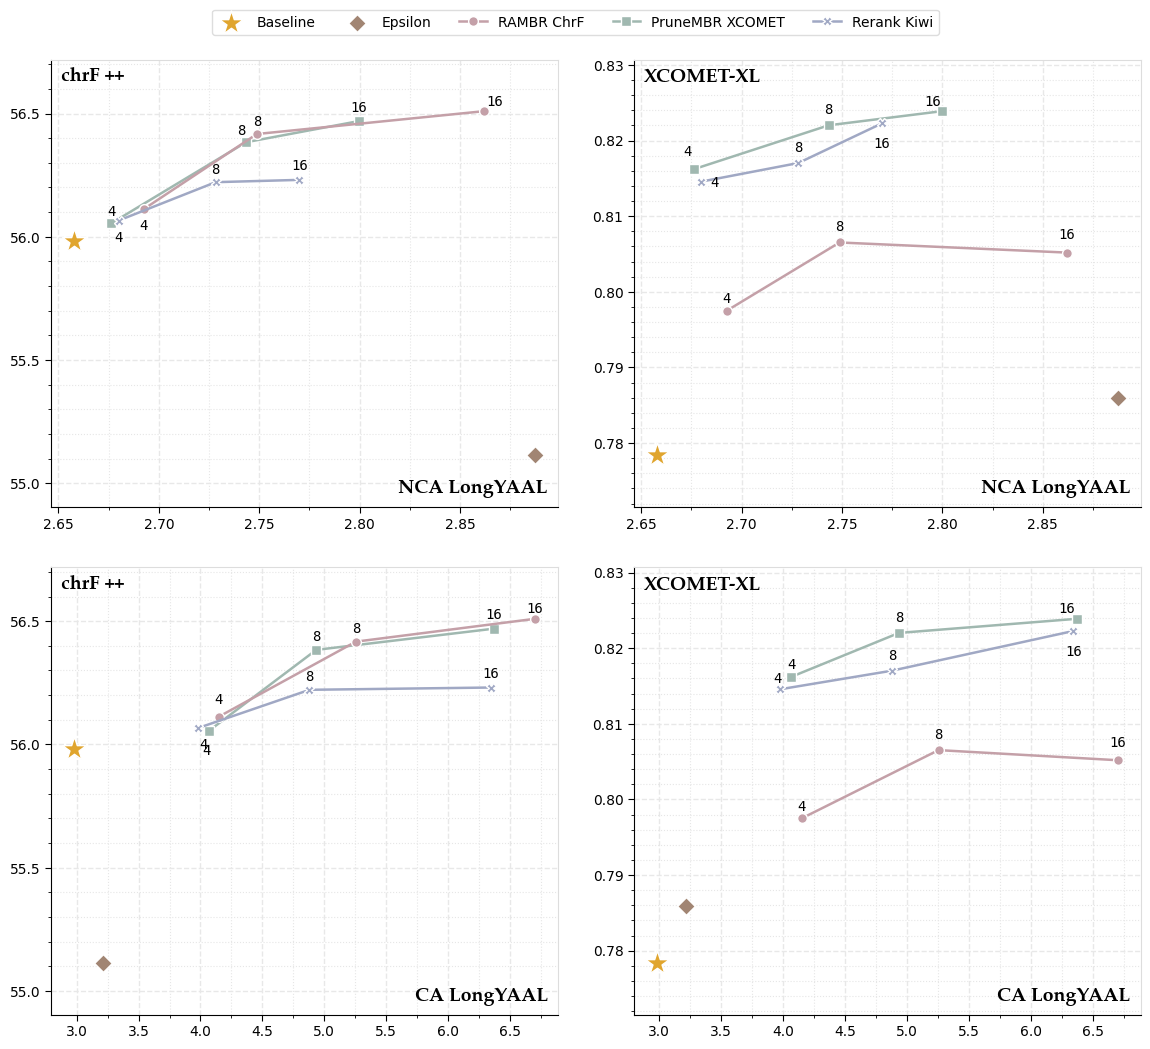

In [5]:
df_mbr = pd.read_csv(BASE / "experiments/mbr_trades/cascade_2026_mbr/results_cascade_2026_mbr.csv")
df_mbr = df_mbr.sort_values(["method", "n_samples"])
df_mbr = df_mbr[df_mbr["n_samples"] != 32]

df_epsilon = pd.read_csv(BASE / "experiments/mbr_trades/cascade_2026_epsilon/results_cascade_2026_epsilon.csv")
row_epsilon = df_epsilon[df_epsilon["jsonl_file"] == "cascade_2026_epsilon_seg960"].iloc[0]

df_baseline = pd.read_csv(BASE / "experiments/baselines_trades/cascade_2026/results_cascade_2026.csv")
row_baseline = df_baseline[df_baseline["jsonl_file"] == "cascade_2026_seg960"].iloc[0]

fig, axes = plt.subplots(2, 2, figsize=(12, 10.5))

COLORS = {
    "rambr_chrf":      "#c4a0a8",
    "prunembr_xcomet": "#a0b8b0",
    "rerank_kiwi":     "#a0a8c4",
    "epsilon":         "#a18573",
    "baseline":        "#e0a52e",
}

MARKERS = {
    "rambr_chrf":      "o",
    "prunembr_xcomet": "s",
    "rerank_kiwi":     "X",
    "epsilon":         "D",
    "baseline":        "*",
}

SIZES = {
    "rambr_chrf":      7,
    "prunembr_xcomet": 7,
    "rerank_kiwi":     7,
    "epsilon":         7.5,
    "baseline":        15,
}

LABELS = {
    "rambr_chrf":      "RAMBR ChrF",
    "prunembr_xcomet": "PruneMBR XCOMET",
    "rerank_kiwi":     "Rerank Kiwi",
    "epsilon":         "Epsilon",
    "baseline":        "Baseline",
}

LEGEND_ORDER = ["baseline", "epsilon", "rambr_chrf", "prunembr_xcomet", "rerank_kiwi"]

configs = [
    ("long_yaal_nca", "NCA LongYAAL", "chrf_pp",  "chrF ++",   0.5,  0.1),
    ("long_yaal_nca", "NCA LongYAAL", "comet_xl", "XCOMET-XL", 0.01, 0.002),
    ("long_yaal_ca",  "CA LongYAAL",  "chrf_pp",  "chrF ++",   0.5,  0.1),
    ("long_yaal_ca",  "CA LongYAAL",  "comet_xl", "XCOMET-XL", 0.01, 0.002),
]

DEFAULT_GAP = {
    "chrf_pp":  0.002,
    "comet_xl": 0.00015,
}

MANUAL_OFFSETS = {
    ("rerank_kiwi",     4,  "long_yaal_nca", "chrf_pp"):  (0.0,    -0.04,   "top",    "center"),
    ("rambr_chrf",      4,  "long_yaal_nca", "chrf_pp"):  (0.0,    -0.04,   "top",    "center"),
    ("prunembr_xcomet", 4,  "long_yaal_ca",  "chrf_pp"):  (-0.015, -0.05,   "top",    "center"),
    ("rerank_kiwi",     4,  "long_yaal_ca",  "chrf_pp"):  (+0.05,  -0.04,   "top",    "center"),
    ("rambr_chrf",      4,  "long_yaal_ca",  "chrf_pp"):  (0.0,     0.04,   "bottom", "center"),
    ("rerank_kiwi",     16, "long_yaal_nca", "comet_xl"): (0.0,    -0.0018, "top",    "center"),
    ("rerank_kiwi",     16, "long_yaal_ca",  "comet_xl"): (0.0,    -0.0018, "top",    "center"),
}

handle_map = {}

for idx, (xcol, xlabel, ycol, ylabel, tick_step, minor_step) in enumerate(configs):
    ax = axes[idx // 2][idx % 2]

    ax.set_facecolor("white")
    ax.grid(which="major", color=COLOR_MAIN, linewidth=WIDTH_MAIN, linestyle="--", zorder=0)
    ax.grid(which="minor", color=COLOR_SUB, linewidth=WIDTH_SUB, linestyle=":",  zorder=0)
    ax.spines["bottom"].set_color("black")
    ax.spines["left"].set_color("black")
    ax.spines["top"].set_color("#dddddd")
    ax.spines["right"].set_color("#dddddd")
    ax.tick_params(which="major", colors="#000000", length=4, labelsize=10)
    ax.tick_params(which="minor", colors="#000000", length=2, labelsize=7)
    ax.tick_params(axis="y", colors="#000000")
    ax.tick_params(axis="x", colors="#000000")
    ax.tick_params(top=False, which="both")

    gap = DEFAULT_GAP[ycol]
    texts = []

    for method, group in df_mbr.groupby("method"):
        color  = COLORS[method]
        marker = MARKERS[method]
        line, = ax.plot(group[xcol], group[ycol],
                        color=color, linewidth=1.8,
                        marker=marker, markersize=SIZES[method],
                        markerfacecolor=color,
                        markeredgecolor="white",
                        markeredgewidth=1,
                        zorder=3)
        if idx == 0:
            handle_map[method] = line

        for _, row in group.iterrows():
            key = (method, int(row["n_samples"]), xcol, ycol)
            if key in MANUAL_OFFSETS:
                dx, dy, va, ha = MANUAL_OFFSETS[key]
                ax.text(row[xcol] + dx, row[ycol] + dy,
                        str(int(row["n_samples"])),
                        fontsize=10, color="#000000", fontfamily="monospace",
                        va=va, ha=ha)
            else:
                n = int(row["n_samples"])
                if n == 16:
                    extra = 6
                elif n == 8:
                    extra = 4
                else:
                    extra = 1.0
                t = ax.text(row[xcol], row[ycol] + gap * extra,
                            str(n),
                            fontsize=10, color="#000000", fontfamily="monospace",
                            va="bottom", ha="center")
                texts.append(t)

    for key, row in [("baseline", row_baseline), ("epsilon", row_epsilon)]:
        color  = COLORS[key]
        marker = MARKERS[key]
        s_area = (SIZES[key] * 1.2) ** 2
        sc = ax.scatter(row[xcol], row[ycol],
                        color=color, marker=marker, s=s_area,
                        edgecolors="white", linewidths=1.0,
                        zorder=4)
        if idx == 0:
            handle_map[key] = sc

    adjust_text(texts, ax=ax,
                expand_points=(8, 8),
                expand_text=(4, 4),
                force_text=3, force_points=2)

    ymin = min(df_mbr[ycol].min(), row_epsilon[ycol], row_baseline[ycol])
    ymax = max(df_mbr[ycol].max(), row_epsilon[ycol], row_baseline[ycol])
    yrange_data = ymax - ymin
    PAD_BOT, PAD_TOP = 0.15, 0.15
    ax.set_ylim(ymin - yrange_data * PAD_BOT, ymax + yrange_data * PAD_TOP)

    ax.yaxis.set_major_locator(MultipleLocator(tick_step))
    ax.yaxis.set_minor_locator(MultipleLocator(minor_step))
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))

    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.text(0.98, 0.02, xlabel,
            transform=ax.transAxes,
            fontsize=FONT_SIZE, fontfamily=FONT, fontweight="bold",
            ha="right", va="bottom", color="#000000", zorder=5)

    ax.text(0.02, 0.98, ylabel,
            transform=ax.transAxes,
            fontsize=FONT_SIZE, fontfamily=FONT, fontweight="bold",
            ha="left", va="top", color="#000000", zorder=5)

# ── Leyenda ────────────────────────────────────────────────────────────────
handles       = [handle_map[k] for k in LEGEND_ORDER]
legend_labels = [LABELS[k]     for k in LEGEND_ORDER]

fig.legend(handles, legend_labels,
           loc="upper center",
           bbox_to_anchor=(0.5, 1.02),
           ncol=5,
           fontsize=10,
           frameon=True,
           framealpha=0.9,
           edgecolor="#dddddd")

fig.patch.set_facecolor("white")
plt.tight_layout(pad=2.5)

out_eps = BASE / "eps/experiments/cascade_2026_mbr_plot.eps"
out = BASE / "experiments/mbr_trades/cascade_2026_mbr/cascade_2026_mbr_plot"
plt.savefig(out.with_suffix(".png"), dpi=750, bbox_inches="tight", facecolor="white")
legend = fig.legends[0]
legend.get_frame().set_alpha(1.0)
plt.savefig(out_eps, bbox_inches="tight", facecolor="white")
plt.show()

## Cascade LLM-Based Baseline + Epsilon + Utterance MBR

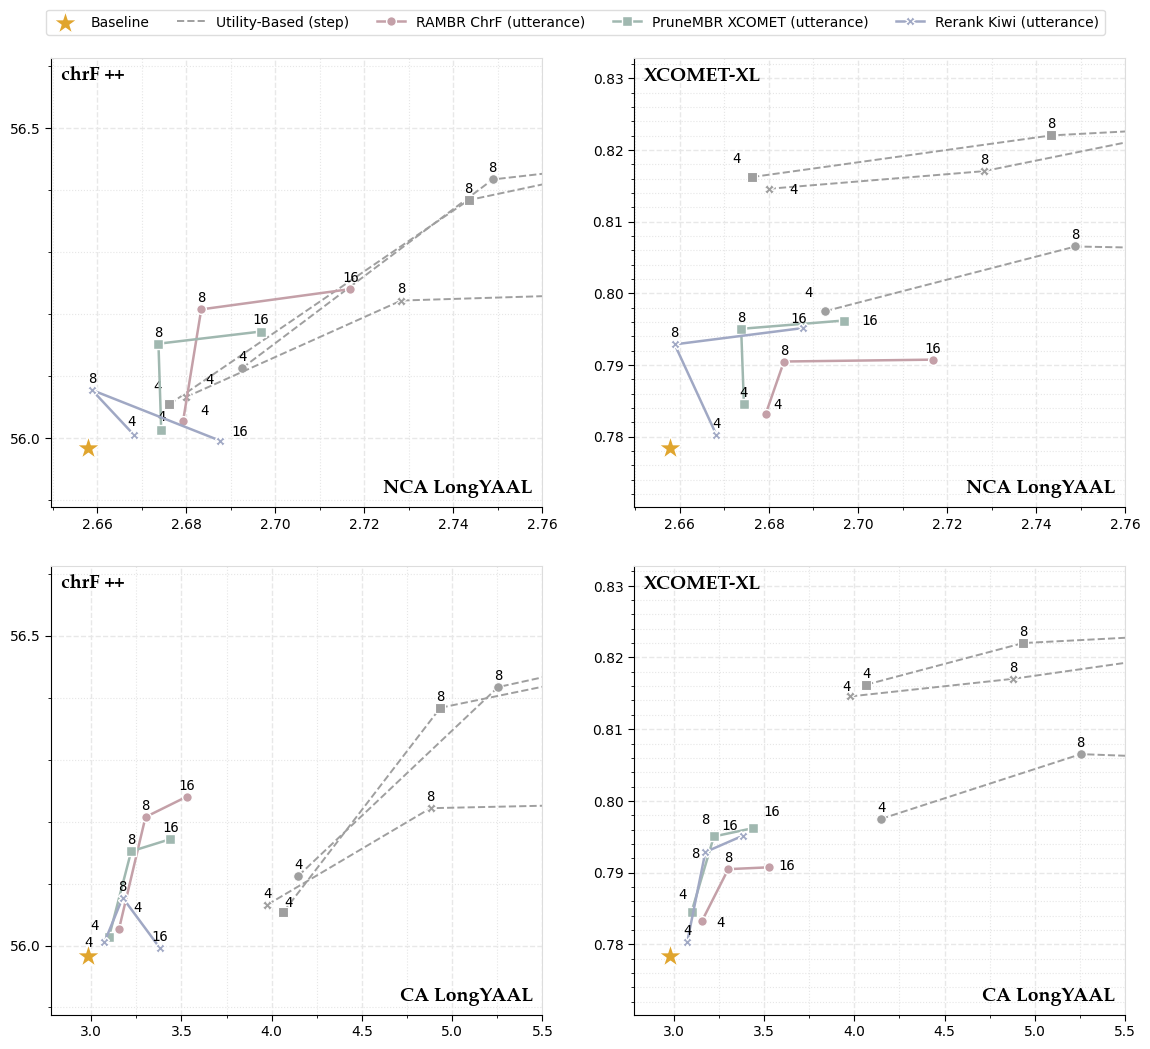

In [6]:
df_full = pd.read_csv(BASE / "experiments/mbr_trades/cascade_2026_mbr/results_cascade_2026_mbr.csv")
df_full = df_full[df_full["n_samples"] != 32].sort_values(["method", "n_samples"])

df_part = pd.read_csv(BASE / "experiments/mbr_trades/cascade_2026_partial_mbr/results_cascade_2026_partial_mbr.csv")
df_part = df_part[df_part["n_samples"] != 32].sort_values(["method", "n_samples"])

df_baseline = pd.read_csv(BASE / "experiments/baselines_trades/cascade_2026/results_cascade_2026.csv")
row_baseline = df_baseline[df_baseline["jsonl_file"] == "cascade_2026_seg960"].iloc[0]

fig, axes = plt.subplots(2, 2, figsize=(12, 10.5))

COLORS = {
    "rambr_chrf":      "#c4a0a8",
    "prunembr_xcomet": "#a0b8b0",
    "rerank_kiwi":     "#a0a8c4",
}

MARKERS = {
    "rambr_chrf":      "o",
    "prunembr_xcomet": "s",
    "rerank_kiwi":     "X",
}

LABELS = {
    "rambr_chrf":      "RAMBR ChrF (utterance)",
    "prunembr_xcomet": "PruneMBR XCOMET (utterance)",
    "rerank_kiwi":     "Rerank Kiwi (utterance)",
}

FULL_GRAY  = "#9F9F9F"
BASE_GOLD  = "#e0a52e"

METHOD_ORDER = ["rambr_chrf", "prunembr_xcomet", "rerank_kiwi"]

configs = [
    ("long_yaal_nca", "NCA LongYAAL", "chrf_pp",  "chrF ++",   0.5,  0.1),
    ("long_yaal_nca", "NCA LongYAAL", "comet_xl", "XCOMET-XL", 0.01, 0.002),
    ("long_yaal_ca",  "CA LongYAAL",  "chrf_pp",  "chrF ++",   0.5,  0.1),
    ("long_yaal_ca",  "CA LongYAAL",  "comet_xl", "XCOMET-XL", 0.01, 0.002),
]

# ── Calcular ylim global por métrica ──────────────────────────────────────
YLIM_GLOBAL = {}
for ycol in ["chrf_pp", "comet_xl"]:
    ally = list(df_full[ycol]) + list(df_part[ycol]) + [row_baseline[ycol]]
    ymin, ymax = min(ally), max(ally)
    yr = ymax - ymin
    YLIM_GLOBAL[ycol] = (ymin - yr * 0.18, ymax + yr * 0.195)

handle_map = {}

for idx, (xcol, xlabel, ycol, ylabel, tick_step, minor_step) in enumerate(configs):
    ax = axes[idx // 2][idx % 2]

    xmax_clip  = 2.76 if xcol == "long_yaal_nca" else 5.5
    df_full_ax = df_full[df_full[xcol] <= xmax_clip]
    df_part_ax = df_part[df_part[xcol] <= xmax_clip]

    ax.set_facecolor("white")
    ax.grid(which="major", color=COLOR_MAIN, linewidth=WIDTH_MAIN, linestyle="--", zorder=0)
    ax.grid(which="minor", color=COLOR_SUB, linewidth=WIDTH_SUB, linestyle=":",  zorder=0)
    ax.spines["bottom"].set_color("black")
    ax.spines["left"].set_color("black")
    ax.spines["top"].set_color("#dddddd")
    ax.spines["right"].set_color("#dddddd")
    ax.tick_params(which="major", colors="#000000", length=4, labelsize=10)
    ax.tick_params(which="minor", colors="#000000", length=2, labelsize=0)
    ax.tick_params(axis="y", colors="#000000")
    ax.tick_params(axis="x", colors="#000000")
    ax.tick_params(top=False, which="both")

    texts = []

    # ── FULL MBR: gris, de-enfatizado ─────────────────────────────────────
    for method in METHOD_ORDER:
        group_full = df_full[df_full["method"] == method]
        group_clip = df_full_ax[df_full_ax["method"] == method]

        ax.plot(group_full[xcol], group_full[ycol],
                color=FULL_GRAY, linewidth=1.4, linestyle="--",
                marker=None, zorder=2)

        ax.plot(group_clip[xcol], group_clip[ycol],
                color=FULL_GRAY, linewidth=0, linestyle="",
                marker=MARKERS[method], markersize=7,
                markerfacecolor=FULL_GRAY, markeredgecolor="white", markeredgewidth=0.8,
                zorder=2)
        for _, row in group_clip.iterrows():
            n = int(row["n_samples"])
            gap = 0.002 if ycol == "chrf_pp" else 0.00015
            t = ax.text(row[xcol], row[ycol] + gap, str(n),
                        fontsize=10, color="#000000", fontfamily="monospace",
                        ha="center", va="bottom")
            texts.append(t)

    # ── PARTIAL MBR: en color ──────────────────────────────────────────────
    for method in METHOD_ORDER:
        group_full = df_part[df_part["method"] == method]
        group_clip = df_part_ax[df_part_ax["method"] == method]
        color      = COLORS[method]

        ax.plot(group_full[xcol], group_full[ycol],
                color=color, linewidth=1.8, linestyle="-",
                marker=None, zorder=3)

        line, = ax.plot(group_clip[xcol], group_clip[ycol],
                        color=color, linewidth=0, linestyle="",
                        marker=MARKERS[method], markersize=7,
                        markerfacecolor=color, markeredgecolor="white", markeredgewidth=1,
                        zorder=3)
        if idx == 0:
            handle_map[method] = line
        for _, row in group_clip.iterrows():
            n = int(row["n_samples"])
            gap = 0.002 if ycol == "chrf_pp" else 0.00015
            t = ax.text(row[xcol], row[ycol] + gap, str(n),
                        fontsize=10, color="#000000", fontfamily="monospace",
                        ha="center", va="bottom")
            texts.append(t)

    # ── Baseline ───────────────────────────────────────────────────────────
    base_h = ax.scatter(row_baseline[xcol], row_baseline[ycol],
                        color=BASE_GOLD, marker="*", s=(15 * 1.2) ** 2,
                        edgecolors="white", linewidths=1.0, zorder=5)
    if idx == 0:
        handle_map["baseline"] = base_h

    adjust_text(texts, ax=ax,
                expand_points=(8, 8),
                expand_text=(4, 4),
                force_text=3, force_points=2)

    ax.set_ylim(*YLIM_GLOBAL[ycol])

    allx = list(df_full_ax[xcol]) + list(df_part_ax[xcol]) + [row_baseline[xcol]]
    xmin = min(allx)
    xr   = xmax_clip - xmin
    ax.set_xlim(xmin - xr * 0.08, xmax_clip)

    ax.yaxis.set_major_locator(MultipleLocator(tick_step))
    ax.yaxis.set_minor_locator(MultipleLocator(minor_step))
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))

    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.text(0.98, 0.02, xlabel,
            transform=ax.transAxes,
            fontsize=FONT_SIZE, fontfamily=FONT, fontweight="bold",
            ha="right", va="bottom", color="#000000", zorder=5)

    ax.text(0.02, 0.98, ylabel,
            transform=ax.transAxes,
            fontsize=FONT_SIZE, fontfamily=FONT, fontweight="bold",
            ha="left", va="top", color="#000000", zorder=5)

# ── Leyenda ────────────────────────────────────────────────────────────────
full_proxy = Line2D([0], [0], color=FULL_GRAY, linewidth=1.4, linestyle="--")

part_proxies = {
    method: Line2D([0], [0], color=COLORS[method], linewidth=1.8, linestyle="-",
                   marker=MARKERS[method], markersize=7,
                   markerfacecolor=COLORS[method], markeredgecolor="white", markeredgewidth=1)
    for method in METHOD_ORDER
}

handles = [handle_map["baseline"], full_proxy] + [part_proxies[m] for m in METHOD_ORDER]
legend_labels = ["Baseline", "Utility-Based (step)"] + [LABELS[m] for m in METHOD_ORDER]

fig.legend(handles, legend_labels,
           loc="upper center",
           bbox_to_anchor=(0.5, 1.02),
           ncol=5,
           fontsize=10,
           frameon=True,
           framealpha=0.9,
           edgecolor="#dddddd")

fig.patch.set_facecolor("white")
plt.tight_layout(pad=2.5)

out_eps = BASE / "eps/experiments/cascade_2026_partial_vs_full.eps"
out = BASE / "experiments/mbr_trades/cascade_2026_partial_mbr/cascade_2026_partial_vs_full"
plt.savefig(out.with_suffix(".png"), dpi=750, bbox_inches="tight", facecolor="white")
legend = fig.legends[0]
legend.get_frame().set_alpha(1.0)
plt.savefig(out_eps, bbox_inches="tight", facecolor="white")
plt.show()

# PART 3: EMISSION POLICY ANALYSIS

## Latency Distribution ASR

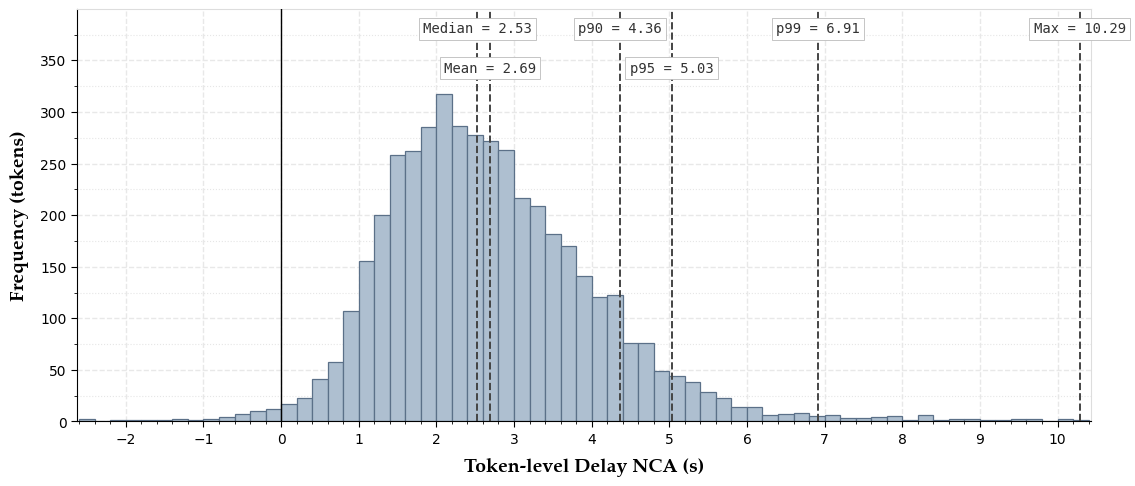

In [7]:
df_tok = pd.read_csv(BASE / "experiments/policies_trades/asr/latencies_asr_study/latency_per_token_asr.csv")

vals = df_tok[(df_tok["policy"] == "local_agreement") & (df_tok["variant"] == "cu") & (df_tok["run_tag"].str.contains("comet"))]["lag"].to_numpy()
vals = vals / 1000.0

stats = {
    "Mean":    np.mean(vals),
    "Median":  np.median(vals),
    "p90":     np.percentile(vals, 90),
    "p95":     np.percentile(vals, 95),
    "p99":     np.percentile(vals, 99),
    "Max":     np.max(vals),
}

STAT_COLORS = {
    "Mean":    "#5e8f80",
    "Median":  "#6a7aae",
    "p90":     "#c79a52",
    "p95":     "#c77f52",
    "p99":     "#b0566a",
    "Max":     "#8c3a4a",
}

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.set_facecolor("white")
ax.grid(which="major", color=COLOR_MAIN, linewidth=WIDTH_MAIN, linestyle="--", zorder=0)
ax.grid(which="minor", axis="y", color=COLOR_SUB, linewidth=WIDTH_SUB, linestyle=":", zorder=0)
ax.spines["bottom"].set_color("black")
ax.spines["left"].set_color("black")
ax.spines["top"].set_color("#dddddd")
ax.spines["right"].set_color("#dddddd")
ax.tick_params(axis="x", which="major", colors="#000000", length=4, labelsize=10)
ax.tick_params(axis="x", which="minor", colors="#000000", length=2, labelsize=0)
ax.tick_params(axis="y", which="major", colors="#000000", length=4, labelsize=10)
ax.tick_params(axis="y", which="minor", colors="#000000", length=2, labelsize=0)
ax.tick_params(top=False, which="both")

BIN_W = 0.2
edges = np.arange(np.floor(vals.min() / BIN_W) * BIN_W,
                  np.ceil(vals.max() / BIN_W) * BIN_W + BIN_W, BIN_W)
ax.hist(vals, bins=edges, color="#aebfd0", edgecolor="#5b7088", linewidth=0.9, zorder=2)

PAD = 0.20
ymax = ax.get_ylim()[1]
ax.set_ylim(0, ymax * (1 + PAD))
ax.set_xlim(edges[0] - BIN_W * 0.15, edges[-1] + BIN_W * 0.15)

ax.xaxis.set_major_locator(MultipleLocator(1.0))
ax.xaxis.set_minor_locator(MultipleLocator(0.2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

if vals.min() < 0 < vals.max():
    ax.axvline(0, color="black", linewidth=1.0, linestyle="-", zorder=4)

xrange = vals.max() - vals.min()
ytop = ax.get_ylim()[1]
levels = [0.97, 0.875, 0.78, 0.685]
min_gap = xrange * 0.11
last_x = -np.inf
li = 0
for label, x in sorted(stats.items(), key=lambda kv: kv[1]):
    li = (li + 1) % len(levels) if (x - last_x) < min_gap else 0
    y = ytop * levels[li]
    ax.axvline(x, color="#444444", linewidth=1.4, linestyle="--", zorder=5)
    ax.text(x, y, f"{label} = {x:.2f}", color="#333333",
            fontsize=10, fontfamily="monospace", ha="center", va="top", zorder=6,
            bbox=dict(boxstyle="square,pad=0.3", facecolor="white",
                      edgecolor="#bbbbbb", linewidth=0.6))
    last_x = x

ax.set_xlabel("Token-level Delay NCA (s)", fontsize=FONT_SIZE, labelpad=8,
              fontfamily=FONT, fontweight="bold")
ax.set_ylabel("Frequency (tokens)", fontsize=FONT_SIZE, labelpad=8,
              fontfamily=FONT, fontweight="bold")

fig.patch.set_facecolor("white")
plt.tight_layout(pad=3)

out_eps = BASE / "eps/experiments/local_agreement_distribution_token.eps"
out = BASE / "experiments/policies_trades/asr/latencies_asr_study/local_agreement_distribution_token"
plt.savefig(out.with_suffix(".png"), dpi=550, bbox_inches="tight", facecolor="white")
plt.savefig(out_eps, bbox_inches="tight", facecolor="white")
plt.show()

In [8]:
df_tok = pd.read_csv(BASE / "experiments/policies_trades/asr/latencies_asr_study/latency_per_token_asr.csv")

POLICY_ORDER = [
    "local_agreement",
    "hold_n1", "hold_n2", "hold_n4",
    "tolerant_tau1", "tolerant_tau2", "tolerant_tau3",
]

STAT_COLS = ["mean_lag", "median_lag", "p90", "p95", "p99", "max_lag"]

DECODERS = ["rambr_chrf", "prunembr_xcomet", "rerank_kiwi"]

def extract_decoder(run_name):
    if "prunembr_xcomet" in run_name:
        return "prunembr_xcomet"
    elif "rambr_chrf" in run_name:
        return "rambr_chrf"
    elif "rerank_kiwi" in run_name:
        return "rerank_kiwi"
    else:
        return "unknown"

df_tok["decoder"] = df_tok["run_tag"].apply(extract_decoder)

for decoder in DECODERS:
    for variant in ["cu", "ca"]:
        df_v = df_tok[(df_tok["variant"] == variant) & (df_tok["decoder"] == decoder)]

        if df_v.empty:
            print(f"\nNo data for {decoder} / {variant.upper()}, skipping.")
            continue

        metrics_agg = (
            df_v
            .groupby("policy")["lag"]
            .agg(
                mean_lag="mean",
                median_lag="median",
                p90=lambda x: x.quantile(0.90),
                p95=lambda x: x.quantile(0.95),
                p99=lambda x: x.quantile(0.99),
                max_lag="max"
            )
            .reset_index()
        )

        for col in STAT_COLS:
            metrics_agg[col] = metrics_agg[col].round(2)

        print(f"\n{'='*60}")
        print(f"  SUMMARY, {decoder}  ({variant.upper()})")
        print(f"{'='*60}")
        display(
            metrics_agg
            .set_index("policy")
            .loc[[p for p in POLICY_ORDER if p in metrics_agg["policy"].values]]
            .style
            .format({c: "{:.2f}" for c in STAT_COLS})
            .background_gradient(subset=STAT_COLS, cmap="RdYlGn_r")
        )


  SUMMARY, rambr_chrf  (CU)


,mean_lag,median_lag,p90,p95,p99,max_lag
policy,,,,,,
local_agreement,2626.53,2490.88,4336.95,4990.00,6872.67,10285.33
hold_n1,722.19,658.25,1773.10,2196.49,3193.93,5050.09
hold_n2,1297.84,1191.92,2763.65,3344.56,4487.88,8441.25
hold_n4,2409.60,2176.02,4681.75,5640.75,7869.17,11630.81
tolerant_tau1,2596.46,2471.98,4275.99,4892.48,6459.81,8335.86
tolerant_tau2,2569.69,2452.86,4244.28,4842.61,6411.19,8233.73
tolerant_tau3,2627.90,2476.37,4280.64,4900.65,6516.34,8233.73



  SUMMARY, rambr_chrf  (CA)


,mean_lag,median_lag,p90,p95,p99,max_lag
policy,,,,,,
local_agreement,3209.21,3008.91,5046.89,5812.13,8132.61,11048.04
hold_n1,2014.09,1911.76,3300.85,3822.05,4920.23,7428.69
hold_n2,3148.47,2991.10,4935.70,5713.09,7021.25,9663.41
hold_n4,5177.83,4964.52,7720.68,8873.66,11361.03,15197.22
tolerant_tau1,3119.88,2940.13,4900.55,5610.61,7456.08,10054.60
tolerant_tau2,3095.58,2922.40,4858.14,5535.17,7383.50,10038.37
tolerant_tau3,3143.34,2951.34,4897.09,5595.04,7456.55,10040.58



  SUMMARY, prunembr_xcomet  (CU)


...

,mean_lag,median_lag,p90,p95,p99,max_lag
policy,,,,,,
local_agreement,3246.56,3027.88,5063.49,5850.50,8183.12,11050.93
hold_n1,2045.76,1957.56,3309.99,3829.46,4941.54,7485.09
hold_n2,3268.33,3100.43,5082.81,5853.53,7136.24,9775.71
hold_n4,5298.67,5055.28,7790.28,9021.99,11432.08,15369.32
tolerant_tau1,3158.67,2971.33,4946.26,5649.59,7448.80,10116.78
tolerant_tau2,3130.65,2935.32,4896.00,5581.39,7337.36,10122.70
tolerant_tau3,3158.17,2968.54,4933.12,5640.48,7447.42,10112.47



  SUMMARY, rerank_kiwi  (CU)


,mean_lag,median_lag,p90,p95,p99,max_lag
policy,,,,,,
local_agreement,2620.09,2480.00,4336.95,4984.37,6879.38,10285.33
hold_n1,754.08,692.94,1737.54,2108.40,3157.35,5050.09
hold_n2,1352.88,1234.45,2851.31,3411.72,4538.73,8441.25
hold_n4,2443.46,2232.00,4707.51,5662.79,7947.51,11964.59
tolerant_tau1,2579.03,2459.90,4262.90,4891.45,6415.58,8335.86
tolerant_tau2,2553.79,2431.46,4229.16,4842.10,6401.70,8233.73
tolerant_tau3,2605.94,2458.76,4265.65,4905.05,6481.22,8233.73



  SUMMARY, rerank_kiwi  (CA)


,mean_lag,median_lag,p90,p95,p99,max_lag
policy,,,,,,
local_agreement,3201.46,2998.94,5050.01,5773.43,8144.19,11051.61
hold_n1,2060.45,1968.76,3296.57,3812.78,4978.99,7450.86
hold_n2,3216.02,3059.13,5069.91,5814.08,7024.95,9655.74
hold_n4,5216.44,4975.94,7754.10,8888.26,11393.26,15206.36
tolerant_tau1,3105.81,2930.50,4862.47,5553.03,7441.48,10060.84
tolerant_tau2,3074.43,2907.88,4802.54,5495.44,7327.62,10060.28
tolerant_tau3,3123.05,2933.52,4850.66,5556.41,7438.10,10076.01


## ASR

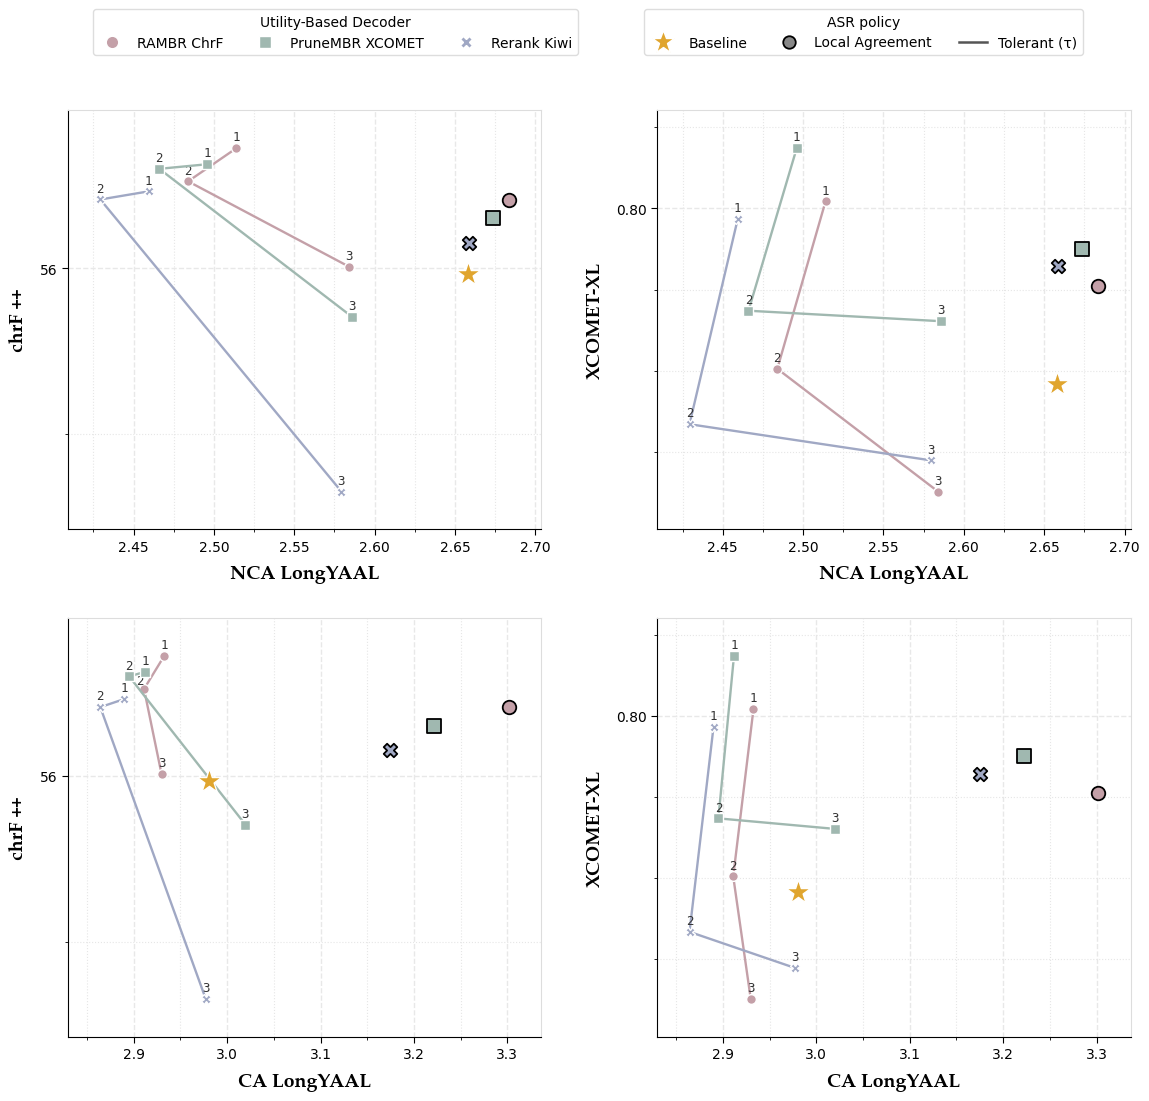

In [9]:
BASE_GOLD = "#e0a52e"

df_part = pd.read_csv(BASE / "experiments/mbr_trades/cascade_2026_partial_mbr/results_cascade_2026_partial_mbr.csv")
df_part8 = df_part[df_part["n_samples"] == 8].copy()

df_asr = pd.read_csv(BASE / "experiments/policies_trades/asr/results_policies_asr.csv")
df_asr = df_asr[~((df_asr["param"] < 12) & (df_asr["policy"] == "hold_n"))].copy()

df_baseline = pd.read_csv(BASE / "experiments/baselines_trades/cascade_2026/results_cascade_2026.csv")
row_baseline = df_baseline[df_baseline["jsonl_file"] == "cascade_2026_seg960"].iloc[0]

fig, axes = plt.subplots(2, 2, figsize=(12, 10.5))

COLORS = {
    "rambr_chrf":      "#c4a0a8",
    "prunembr_xcomet": "#a0b8b0",
    "rerank_kiwi":     "#a0a8c4",
}
MARKERS = {
    "rambr_chrf":      "o",
    "prunembr_xcomet": "s",
    "rerank_kiwi":     "X",
}
DEC_LABELS = {
    "rambr_chrf":      "RAMBR ChrF",
    "prunembr_xcomet": "PruneMBR XCOMET",
    "rerank_kiwi":     "Rerank Kiwi",
}
METHOD_ORDER = ["rambr_chrf", "prunembr_xcomet", "rerank_kiwi"]

POLICY_STYLE = {
    "tolerant_agreement": {"ls": "-",  "label": "Tolerant (\u03c4)"},
    "hold_n":             {"ls": "--", "label": "Hold-n (n)"},
}
POLICY_ORDER = ["tolerant_agreement", "hold_n"]

configs = [
    ("long_yaal_nca", "NCA LongYAAL", "chrf_pp",  "chrF ++",   2.0,  0.5),
    ("long_yaal_nca", "NCA LongYAAL", "comet_xl", "XCOMET-XL", 0.05, 0.01),
    ("long_yaal_ca",  "CA LongYAAL",  "chrf_pp",  "chrF ++",   2.0,  0.5),
    ("long_yaal_ca",  "CA LongYAAL",  "comet_xl", "XCOMET-XL", 0.05, 0.01),
]

for idx, (xcol, xlabel, ycol, ylabel, tick_step, minor_step) in enumerate(configs):
    ax = axes[idx // 2][idx % 2]
    ax.set_facecolor("white")
    ax.grid(which="major", color=COLOR_MAIN, linewidth=WIDTH_MAIN, linestyle="--", zorder=0)
    ax.grid(which="minor", color=COLOR_SUB, linewidth=WIDTH_SUB, linestyle=":",  zorder=0)
    ax.spines["bottom"].set_color("black")
    ax.spines["left"].set_color("black")
    ax.spines["top"].set_color("#dddddd")
    ax.spines["right"].set_color("#dddddd")
    ax.tick_params(which="major", colors="#000000", length=4)
    ax.tick_params(which="minor", colors="#000000", length=2)

    texts = []

    # politicas ASR: linea por (policy, decoder), barriendo el parametro
    for policy in POLICY_ORDER:
        ls = POLICY_STYLE[policy]["ls"]
        for method in METHOD_ORDER:
            g = df_asr[(df_asr["policy"] == policy) & (df_asr["method"] == method)].sort_values("param")
            if g.empty:
                continue
            ax.plot(g[xcol], g[ycol],
                    color=COLORS[method], linewidth=1.7, linestyle=ls,
                    marker=MARKERS[method], markersize=7,
                    markerfacecolor=COLORS[method], markeredgecolor="white", markeredgewidth=1,
                    zorder=3)
            for _, row in g.iterrows():
                t = ax.text(row[xcol], row[ycol], str(int(row["param"])),
                            fontsize=9, color="#333333", fontfamily="monospace",
                            ha="center", va="bottom")
                texts.append(t)

    # local agreement (partial n=8): marcador suelto con borde negro
    for method in METHOD_ORDER:
        g = df_part8[df_part8["method"] == method]
        ax.scatter(g[xcol], g[ycol],
                   color=COLORS[method], marker=MARKERS[method], s=95,
                   edgecolors="black", linewidths=1.3, zorder=4)

    # baseline: estrella dorada
    ax.scatter(row_baseline[xcol], row_baseline[ycol],
               color=BASE_GOLD, marker="*", s=340,
               edgecolors="white", linewidths=1.0, zorder=5)

    allx = list(df_asr[xcol]) + list(df_part8[xcol]) + [row_baseline[xcol]]
    ally = list(df_asr[ycol]) + list(df_part8[ycol]) + [row_baseline[ycol]]
    xr = max(allx) - min(allx); yr = max(ally) - min(ally)
    ax.set_xlim(min(allx) - xr * 0.08, max(allx) + xr * 0.08)
    ax.set_ylim(min(ally) - yr * 0.11, max(ally) + yr * 0.11)

    ax.yaxis.set_major_locator(MultipleLocator(tick_step))
    ax.yaxis.set_minor_locator(MultipleLocator(minor_step))
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))

    adjust_text(texts, ax=ax, expand_points=(1.5, 1.5), expand_text=(1.2, 1.2),
                force_text=1.0, force_points=1.0, only_move={"text": "xy", "points": "xy"})

    ax.set_xlabel(xlabel, fontsize=FONT_SIZE, labelpad=8, fontfamily=FONT, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=FONT_SIZE, labelpad=8, fontfamily=FONT, fontweight="bold")

# Leyenda 1: Decoder (color + forma)
dec_handles = [Line2D([0], [0], color=COLORS[m], marker=MARKERS[m], linestyle="None",
                      markersize=9, markeredgecolor="white") for m in METHOD_ORDER]
dec_labels  = [DEC_LABELS[m] for m in METHOD_ORDER]

# Leyenda 2: ASR policy (baseline primero, luego local agreement y tolerant)
pol_handles = [
    Line2D([0], [0], color=BASE_GOLD, marker="*", linestyle="None",
           markersize=17, markeredgecolor="white", markeredgewidth=1.0),
    Line2D([0], [0], color="#888888", marker="o", linestyle="None",
           markersize=9, markeredgecolor="black", markeredgewidth=1.3),
    Line2D([0], [0], color="#555555", linestyle=POLICY_STYLE["tolerant_agreement"]["ls"], linewidth=1.8),
]
pol_labels = ["Baseline", "Local Agreement", "Tolerant (\u03c4)"]

fig.legend(dec_handles, dec_labels, title="Utility-Based Decoder",
           loc="upper center", bbox_to_anchor=(0.30, 1.07), ncol=3,
           fontsize=10, frameon=True, framealpha=0.9, edgecolor="#dddddd")
fig.legend(pol_handles, pol_labels, title="ASR policy",
           loc="upper center", bbox_to_anchor=(0.74, 1.07), ncol=3,
           fontsize=10, frameon=True, framealpha=0.9, edgecolor="#dddddd")

fig.patch.set_facecolor("white")
plt.tight_layout(pad=2.5)

out = BASE / "experiments/policies_trades/asr/policies_asr_plot"
plt.savefig(out.with_suffix(".png"), dpi=750, bbox_inches="tight", facecolor="white")
for lg in fig.legends:
    lg.get_frame().set_alpha(1.0)
plt.show()

## Latency CU Distribution MT

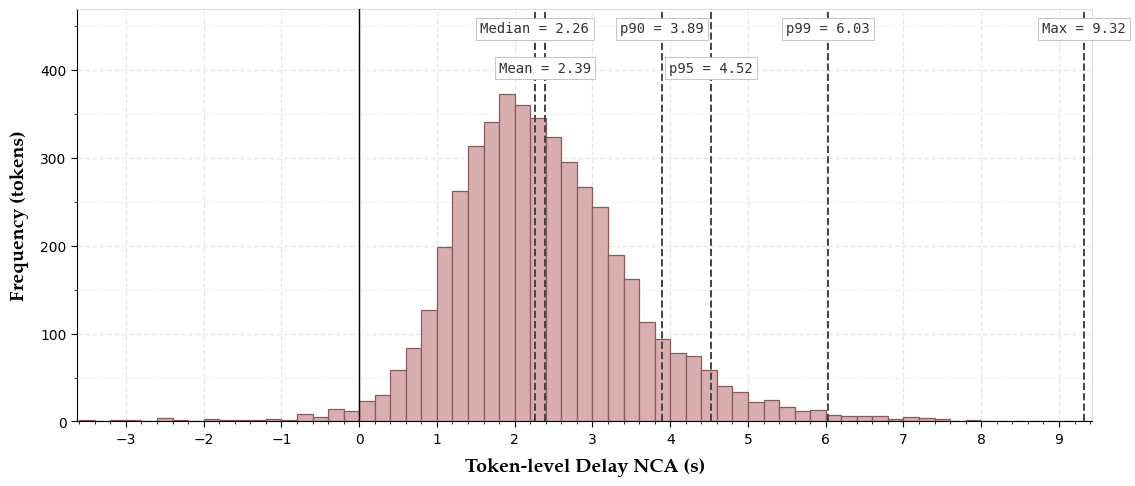

In [10]:
df_tok = pd.read_csv(BASE / "experiments/policies_trades/mt/latencies_mt_study/latency_per_token_mt.csv")

POLICY = "mt_tla_tau1"   # <-- cambia aquí: mt_waitk3, mt_waitk5, mt_tla_tau1/2, mt_hybrid_k{1,3,5}_tau{1,2}

vals = df_tok[(df_tok["policy"] == POLICY) & (df_tok["variant"] == "cu") & (df_tok["run_tag"].str.contains("comet"))]["lag"].to_numpy()
vals = vals / 1000.0

stats = {
    "Mean":    np.mean(vals),
    "Median":  np.median(vals),
    "p90":     np.percentile(vals, 90),
    "p95":     np.percentile(vals, 95),
    "p99":     np.percentile(vals, 99),
    "Max":     np.max(vals),
}

STAT_COLORS = {
    "Mean":    "#5e8f80",
    "Median":  "#6a7aae",
    "p90":     "#c79a52",
    "p95":     "#c77f52",
    "p99":     "#b0566a",
    "Max":     "#8c3a4a",
}

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.set_facecolor("white")
ax.grid(which="major", color=COLOR_MAIN, linewidth=WIDTH_MAIN, linestyle="--", zorder=0)
ax.grid(which="minor", axis="y", color=COLOR_SUB, linewidth=WIDTH_SUB, linestyle=":", zorder=0)
ax.spines["bottom"].set_color("black")
ax.spines["left"].set_color("black")
ax.spines["top"].set_color("#dddddd")
ax.spines["right"].set_color("#dddddd")
ax.tick_params(axis="x", which="major", colors="#000000", length=4, labelsize=10)
ax.tick_params(axis="x", which="minor", colors="#000000", length=2, labelsize=0)
ax.tick_params(axis="y", which="major", colors="#000000", length=4, labelsize=10)
ax.tick_params(axis="y", which="minor", colors="#000000", length=2, labelsize=0)
ax.tick_params(top=False, which="both")

BIN_W = 0.2
edges = np.arange(np.floor(vals.min() / BIN_W) * BIN_W,
                  np.ceil(vals.max() / BIN_W) * BIN_W + BIN_W, BIN_W)
ax.hist(vals, bins=edges, color="#d8aeae", edgecolor="#885b5b", linewidth=0.9, zorder=2)

PAD = 0.20
ymax = ax.get_ylim()[1]
ax.set_ylim(0, ymax * (1 + PAD))
ax.set_xlim(edges[0] - BIN_W * 0.15, edges[-1] + BIN_W * 0.15)

ax.xaxis.set_major_locator(MultipleLocator(1.0))
ax.xaxis.set_minor_locator(MultipleLocator(0.2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

if vals.min() < 0 < vals.max():
    ax.axvline(0, color="black", linewidth=1.0, linestyle="-", zorder=4)

xrange = vals.max() - vals.min()
ytop = ax.get_ylim()[1]
levels = [0.97, 0.875, 0.78, 0.685]
min_gap = xrange * 0.11
last_x = -np.inf
li = 0
for label, x in sorted(stats.items(), key=lambda kv: kv[1]):
    li = (li + 1) % len(levels) if (x - last_x) < min_gap else 0
    y = ytop * levels[li]
    ax.axvline(x, color="#444444", linewidth=1.4, linestyle="--", zorder=5)
    ax.text(x, y, f"{label} = {x:.2f}", color="#333333",
            fontsize=10, fontfamily="monospace", ha="center", va="top", zorder=6,
            bbox=dict(boxstyle="square,pad=0.3", facecolor="white",
                      edgecolor="#bbbbbb", linewidth=0.6))
    last_x = x

ax.set_xlabel("Token-level Delay NCA (s)", fontsize=FONT_SIZE, labelpad=8,
              fontfamily=FONT, fontweight="bold")
ax.set_ylabel("Frequency (tokens)", fontsize=FONT_SIZE, labelpad=8,
              fontfamily=FONT, fontweight="bold")

fig.patch.set_facecolor("white")
plt.tight_layout(pad=3)

out_eps = BASE / f"eps/experiments/{POLICY}_distribution_token.eps"
out = BASE / f"experiments/policies_trades/mt/latencies_mt_study/{POLICY}_distribution_token"
plt.savefig(out.with_suffix(".png"), dpi=550, bbox_inches="tight", facecolor="white")
plt.savefig(out_eps, bbox_inches="tight", facecolor="white")
plt.show()


In [11]:
df_tok = pd.read_csv(BASE / "experiments/policies_trades/mt/latencies_mt_study/latency_per_token_mt.csv")

POLICY_ORDER = [
    "mt_waitk3", "mt_waitk5",
    "mt_tla_tau1", "mt_tla_tau2",
    "mt_hybrid_k1_tau1", "mt_hybrid_k1_tau2",
    "mt_hybrid_k3_tau1", "mt_hybrid_k3_tau2",
    "mt_hybrid_k5_tau1", "mt_hybrid_k5_tau2",
]

STAT_COLS = ["mean_lag", "median_lag", "p90", "p95", "p99", "max_lag"]

DECODERS = ["rambr_chrf", "prunembr_xcomet", "rerank_kiwi"]

def extract_decoder(run_name):
    if "prunembr_xcomet" in run_name:
        return "prunembr_xcomet"
    elif "rambr_chrf" in run_name:
        return "rambr_chrf"
    elif "rerank_kiwi" in run_name:
        return "rerank_kiwi"
    else:
        return "unknown"

df_tok["decoder"] = df_tok["run_tag"].apply(extract_decoder)

for decoder in DECODERS:
    for variant in ["cu", "ca"]:
        df_v = df_tok[(df_tok["variant"] == variant) & (df_tok["decoder"] == decoder)]

        if df_v.empty:
            print(f"\nNo data for {decoder} / {variant.upper()}, skipping.")
            continue

        metrics_agg = (
            df_v
            .groupby("policy")["lag"]
            .agg(
                mean_lag="mean",
                median_lag="median",
                p90=lambda x: x.quantile(0.90),
                p95=lambda x: x.quantile(0.95),
                p99=lambda x: x.quantile(0.99),
                max_lag="max"
            )
            .reset_index()
        )

        for col in STAT_COLS:
            metrics_agg[col] = metrics_agg[col].round(2)

        print(f"\n{'='*60}")
        print(f"  SUMMARY, {decoder}  ({variant.upper()})")
        print(f"{'='*60}")
        display(
            metrics_agg
            .set_index("policy")
            .loc[[p for p in POLICY_ORDER if p in metrics_agg["policy"].values]]
            .style
            .format({c: "{:.2f}" for c in STAT_COLS})
            .background_gradient(subset=STAT_COLS, cmap="RdYlGn_r")
        )



  SUMMARY, rambr_chrf  (CU)


,mean_lag,median_lag,p90,p95,p99,max_lag
policy,,,,,,
mt_waitk3,1669.19,1654.86,3000.53,3533.18,5403.22,8093.84
mt_waitk5,2289.73,2302.40,3658.52,4129.05,5557.07,7267.47
mt_tla_tau1,2366.74,2240.60,3859.37,4487.16,6143.73,9371.00
mt_tla_tau2,2326.13,2208.02,3780.03,4413.55,6045.17,9371.00
mt_hybrid_k1_tau1,2366.74,2240.60,3859.37,4487.16,6143.73,9371.00
mt_hybrid_k1_tau2,2326.13,2208.02,3780.03,4413.55,6045.17,9371.00
mt_hybrid_k3_tau1,2365.68,2240.33,3857.48,4487.02,6143.42,9371.00
mt_hybrid_k3_tau2,2325.08,2208.00,3779.00,4413.49,6044.97,9371.00
mt_hybrid_k5_tau1,2387.66,2266.00,3891.57,4516.79,6202.76,9371.00



  SUMMARY, rambr_chrf  (CA)


,mean_lag,median_lag,p90,p95,p99,max_lag
policy,,,,,,
mt_waitk3,2098.77,2037.81,3467.96,4012.93,5684.28,8531.14
mt_waitk5,2774.14,2750.33,4113.19,4595.76,6001.09,8475.28
mt_tla_tau1,2847.03,2691.54,4439.25,5117.21,6834.70,9966.34
mt_tla_tau2,2795.20,2639.39,4320.82,5007.81,6591.43,9966.67
mt_hybrid_k1_tau1,2845.63,2687.51,4421.17,5104.58,6806.08,9962.75
mt_hybrid_k1_tau2,2795.08,2642.45,4341.42,5015.82,6585.41,9966.47
mt_hybrid_k3_tau1,2841.12,2684.26,4415.91,5099.73,6765.97,9968.57
mt_hybrid_k3_tau2,2792.02,2637.52,4325.03,5013.02,6566.20,9963.36
mt_hybrid_k5_tau1,2870.46,2715.88,4473.79,5136.27,6821.94,9965.05



  SUMMARY, prunembr_xcomet  (CU)


...

,mean_lag,median_lag,p90,p95,p99,max_lag
policy,,,,,,
mt_waitk3,2105.27,2040.78,3437.85,3999.18,5686.21,8531.42
mt_waitk5,2748.68,2734.84,4089.03,4556.28,5590.86,6923.50
mt_tla_tau1,2875.42,2710.46,4497.55,5202.44,6936.23,9965.34
mt_tla_tau2,2803.05,2639.26,4370.67,5077.38,6751.02,9972.98
mt_hybrid_k1_tau1,2879.02,2714.00,4506.03,5218.09,6903.51,9965.95
mt_hybrid_k1_tau2,2801.56,2636.56,4368.40,5073.71,6690.25,9962.86
mt_hybrid_k3_tau1,2875.07,2709.50,4504.93,5210.03,6912.86,9965.84
mt_hybrid_k3_tau2,2802.32,2637.85,4373.37,5078.98,6688.43,9965.44
mt_hybrid_k5_tau1,2908.16,2736.20,4550.47,5248.08,6955.05,9963.83



  SUMMARY, rerank_kiwi  (CU)


,mean_lag,median_lag,p90,p95,p99,max_lag
policy,,,,,,
mt_waitk3,1664.15,1650.46,2977.77,3503.94,5240.29,7456.90
mt_waitk5,2258.61,2290.67,3610.31,4083.53,5047.68,6423.37
mt_tla_tau1,2371.21,2244.81,3878.61,4507.84,6151.06,9371.00
mt_tla_tau2,2320.37,2201.67,3805.94,4431.21,6049.68,9371.00
mt_hybrid_k1_tau1,2371.21,2244.81,3878.61,4507.84,6151.06,9371.00
mt_hybrid_k1_tau2,2320.37,2201.67,3805.94,4431.21,6049.68,9371.00
mt_hybrid_k3_tau1,2370.14,2244.47,3876.34,4507.32,6150.54,9371.00
mt_hybrid_k3_tau2,2319.32,2201.02,3798.17,4431.17,6049.48,9371.00
mt_hybrid_k5_tau1,2395.10,2272.39,3922.75,4537.73,6204.63,9371.00



  SUMMARY, rerank_kiwi  (CA)


,mean_lag,median_lag,p90,p95,p99,max_lag
policy,,,,,,
mt_waitk3,2098.47,2040.42,3422.53,3962.92,5649.50,7888.96
mt_waitk5,2747.99,2743.32,4104.38,4568.67,5551.71,7027.74
mt_tla_tau1,2845.17,2690.53,4418.65,5097.06,6777.23,9966.44
mt_tla_tau2,2774.10,2625.78,4291.57,4949.72,6553.55,9980.61
mt_hybrid_k1_tau1,2845.50,2688.98,4415.40,5093.82,6773.80,9966.26
mt_hybrid_k1_tau2,2774.55,2621.45,4300.04,4945.28,6549.41,9961.91
mt_hybrid_k3_tau1,2842.37,2690.90,4413.71,5080.40,6768.12,9970.46
mt_hybrid_k3_tau2,2773.25,2627.37,4287.94,4945.46,6547.27,9957.69
mt_hybrid_k5_tau1,2873.88,2720.87,4466.02,5115.63,6829.43,9960.41


## MT

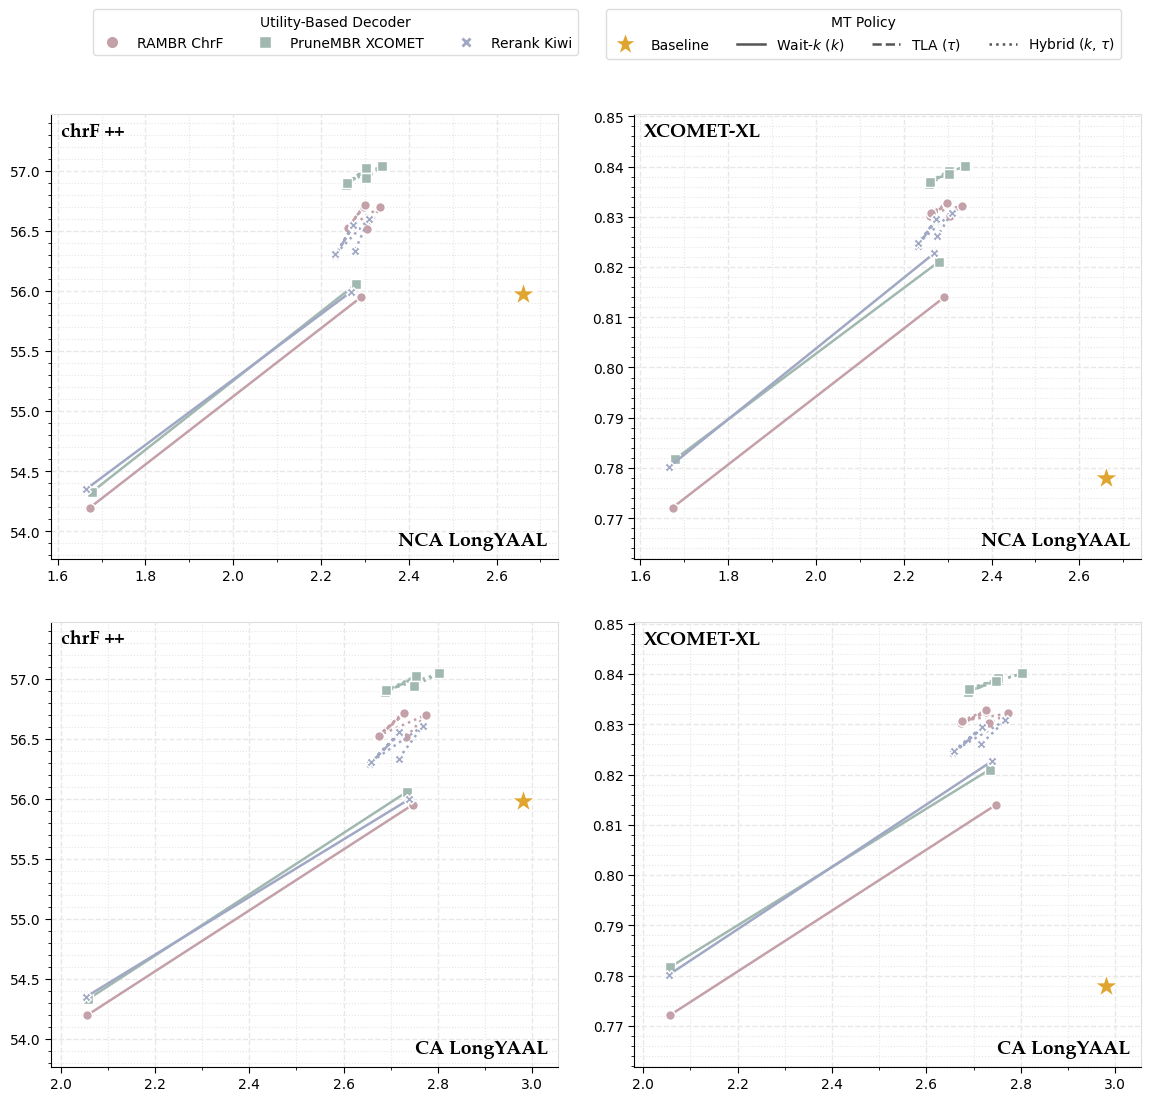

In [12]:
df_mt = pd.read_csv(BASE / "experiments/policies_trades/mt/results_policies_mt.csv")

row_baseline_mt = pd.Series({
    "long_yaal_nca": 2.66,
    "long_yaal_ca":  2.98,
    "chrf_pp":       55.98,
    "comet_xl":      0.778,
})

fig, axes = plt.subplots(2, 2, figsize=(12, 10.5))

COLORS = {
    "rambr_chrf":      "#c4a0a8",
    "prunembr_xcomet": "#a0b8b0",
    "rerank_kiwi":     "#a0a8c4",
}

MARKERS = {
    "rambr_chrf":      "o",
    "prunembr_xcomet": "s",
    "rerank_kiwi":     "X",
}

LABELS = {
    "rambr_chrf":      "RAMBR ChrF",
    "prunembr_xcomet": "PruneMBR XCOMET",
    "rerank_kiwi":     "Rerank Kiwi",
}

BASE_GOLD = "#e0a52e"

METHOD_ORDER = ["rambr_chrf", "prunembr_xcomet", "rerank_kiwi"]

POLICY_ORDER = [
    "mt_waitk3", "mt_waitk5",
    "mt_tla_tau1", "mt_tla_tau2",
    "mt_hybrid_k1_tau1", "mt_hybrid_k1_tau2",
    "mt_hybrid_k3_tau1", "mt_hybrid_k3_tau2",
    "mt_hybrid_k5_tau1", "mt_hybrid_k5_tau2",
]

POLICY_TAG_STYLE = {
    "wait_k":             "-",
    "tolerant_agreement": "--",
    "hybrid_waitk_tla":   ":",
}

configs = [
    ("long_yaal_nca", "NCA LongYAAL", "chrf_pp",  "chrF ++",   0.5,  0.1),
    ("long_yaal_nca", "NCA LongYAAL", "comet_xl", "XCOMET-XL", 0.01, 0.002),
    ("long_yaal_ca",  "CA LongYAAL",  "chrf_pp",  "chrF ++",   0.5,  0.1),
    ("long_yaal_ca",  "CA LongYAAL",  "comet_xl", "XCOMET-XL", 0.01, 0.002),
]

df_mt["policy_order"] = df_mt["policy_tag"].map({p: i for i, p in enumerate(POLICY_ORDER)})
df_mt = df_mt.sort_values(["method", "policy_order"])

YLIM_GLOBAL = {}
for ycol in ["chrf_pp", "comet_xl"]:
    ally = list(df_mt[ycol]) + [row_baseline_mt[ycol]]
    ymin, ymax = min(ally), max(ally)
    yr = ymax - ymin
    YLIM_GLOBAL[ycol] = (ymin - yr * 0.15, ymax + yr * 0.15)

handle_map = {}

for idx, (xcol, xlabel, ycol, ylabel, tick_step, minor_step) in enumerate(configs):
    ax = axes[idx // 2][idx % 2]

    ax.set_facecolor("white")
    ax.grid(which="major", color=COLOR_MAIN, linewidth=WIDTH_MAIN, linestyle="--", zorder=0)
    ax.grid(which="minor", color=COLOR_SUB, linewidth=WIDTH_SUB, linestyle=":",  zorder=0)
    ax.spines["bottom"].set_color("black")
    ax.spines["left"].set_color("black")
    ax.spines["top"].set_color("#dddddd")
    ax.spines["right"].set_color("#dddddd")
    ax.tick_params(which="major", colors="#000000", length=4, labelsize=10)
    ax.tick_params(which="minor", colors="#000000", length=2, labelsize=0)
    ax.tick_params(axis="y", colors="#000000")
    ax.tick_params(axis="x", colors="#000000")
    ax.tick_params(top=False, which="both")

    for method in METHOD_ORDER:
        color = COLORS[method]
        for policy_type, ls in POLICY_TAG_STYLE.items():
            group = (df_mt[(df_mt["method"] == method) &
                           (df_mt["policy"] == policy_type)]
                     .sort_values("policy_order"))
            if group.empty:
                continue
            line, = ax.plot(group[xcol], group[ycol],
                            color=color, linewidth=1.8, linestyle=ls,
                            marker=MARKERS[method], markersize=7,
                            markerfacecolor=color, markeredgecolor="white", markeredgewidth=1,
                            zorder=3)
            if idx == 0 and policy_type == "wait_k":
                handle_map[method] = line

    base_h = ax.scatter(row_baseline_mt[xcol], row_baseline_mt[ycol],
                        color=BASE_GOLD, marker="*", s=(15 * 1.2) ** 2,
                        edgecolors="white", linewidths=1.0, zorder=5)
    if idx == 0:
        handle_map["baseline"] = base_h

    ax.set_ylim(*YLIM_GLOBAL[ycol])

    allx = list(df_mt[xcol]) + [row_baseline_mt[xcol]]
    xmin, xmax = min(allx), max(allx)
    xr = xmax - xmin
    ax.set_xlim(xmin - xr * 0.08, xmax + xr * 0.08)

    ax.yaxis.set_major_locator(MultipleLocator(tick_step))
    ax.yaxis.set_minor_locator(MultipleLocator(minor_step))
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))

    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.text(0.98, 0.02, xlabel,
            transform=ax.transAxes,
            fontsize=FONT_SIZE, fontfamily=FONT, fontweight="bold",
            ha="right", va="bottom", color="#000000", zorder=5)

    ax.text(0.02, 0.98, ylabel,
            transform=ax.transAxes,
            fontsize=FONT_SIZE, fontfamily=FONT, fontweight="bold",
            ha="left", va="top", color="#000000", zorder=5)

# ── Leyenda 1: Decoder ────────────────────────────────────────────────────
dec_handles = [
    Line2D([0], [0], color=COLORS[m], marker=MARKERS[m], linestyle="None",
           markersize=9, markeredgecolor="white")
    for m in METHOD_ORDER
]
dec_labels = [LABELS[m] for m in METHOD_ORDER]

# ── Leyenda 2: MT policy ──────────────────────────────────────────────────
pol_handles = [
    Line2D([0], [0], color=BASE_GOLD, marker="*", linestyle="None",
           markersize=17, markeredgecolor="white", markeredgewidth=1.0),
    Line2D([0], [0], color="#555555", linestyle="-",  linewidth=1.8),
    Line2D([0], [0], color="#555555", linestyle="--", linewidth=1.8),
    Line2D([0], [0], color="#555555", linestyle=":",  linewidth=1.8),
]
pol_labels = ["Baseline", "Wait-$k$ ($k$)", "TLA ($\\tau$)", "Hybrid ($k$, $\\tau$)"]

fig.legend(dec_handles, dec_labels, title="Utility-Based Decoder",
           loc="upper center", bbox_to_anchor=(0.30, 1.07), ncol=3,
           fontsize=10, frameon=True, framealpha=0.9, edgecolor="#dddddd")
fig.legend(pol_handles, pol_labels, title="MT Policy",
           loc="upper center", bbox_to_anchor=(0.74, 1.07), ncol=4,
           fontsize=10, frameon=True, framealpha=0.9, edgecolor="#dddddd")

fig.patch.set_facecolor("white")
plt.tight_layout(pad=2.5)

out_eps = BASE / "eps/experiments/mt_policies_plot.eps"
out     = BASE / "experiments/policies_trades/mt/mt_policies_plot"
plt.savefig(out.with_suffix(".png"), dpi=750, bbox_inches="tight", facecolor="white")
for lg in fig.legends:
    lg.get_frame().set_alpha(1.0)
plt.savefig(out_eps, bbox_inches="tight", facecolor="white")
plt.show()

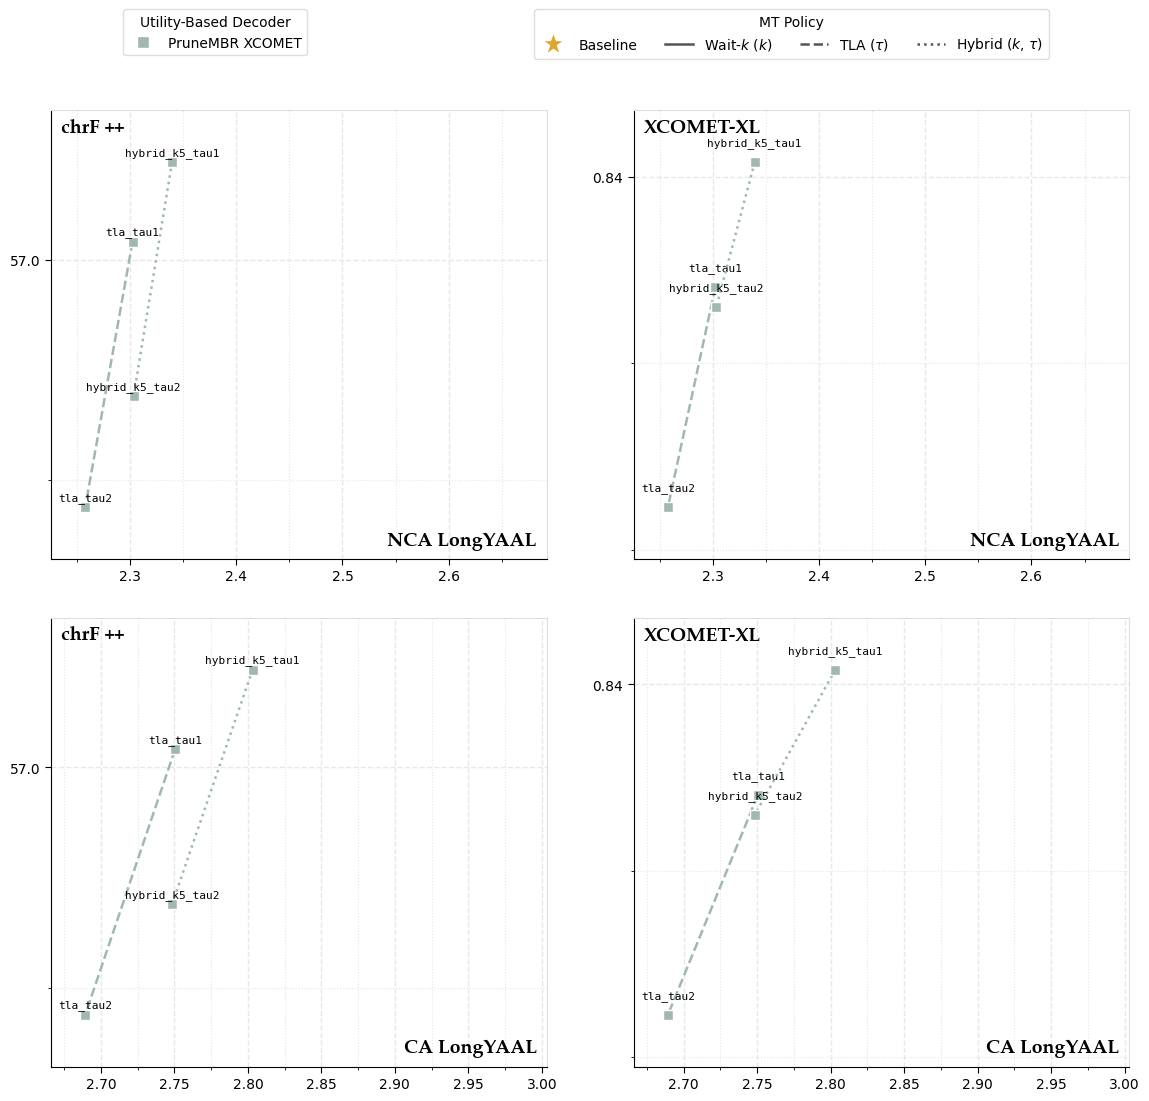

In [13]:
df_mt = pd.read_csv(BASE / "experiments/policies_trades/mt/results_policies_mt.csv")
df_mt = df_mt[df_mt["method"] == "prunembr_xcomet"].copy()

POLICY_ORDER = [
    "mt_tla_tau1", "mt_tla_tau2",
    "mt_hybrid_k5_tau1", "mt_hybrid_k5_tau2",
]

df_mt = df_mt[df_mt["policy_tag"].isin(POLICY_ORDER)].copy()

fig, axes = plt.subplots(2, 2, figsize=(12, 10.5))

COLORS = {
    "rambr_chrf":      "#c4a0a8",
    "prunembr_xcomet": "#a0b8b0",
    "rerank_kiwi":     "#a0a8c4",
}

MARKERS = {
    "rambr_chrf":      "o",
    "prunembr_xcomet": "s",
    "rerank_kiwi":     "X",
}

LABELS = {
    "rambr_chrf":      "RAMBR ChrF",
    "prunembr_xcomet": "PruneMBR XCOMET",
    "rerank_kiwi":     "Rerank Kiwi",
}

BASE_GOLD = "#e0a52e"

METHOD_ORDER = ["rambr_chrf", "prunembr_xcomet", "rerank_kiwi"]

POLICY_ORDER = [
    "mt_waitk5",
    "mt_tla_tau1", "mt_tla_tau2",
    "mt_hybrid_k1_tau1", "mt_hybrid_k1_tau2",
    "mt_hybrid_k3_tau1", "mt_hybrid_k3_tau2",
    "mt_hybrid_k5_tau1", "mt_hybrid_k5_tau2",
]

POLICY_TAG_STYLE = {
    "wait_k":             "-",
    "tolerant_agreement": "--",
    "hybrid_waitk_tla":   ":",
}

configs = [
    ("long_yaal_nca", "NCA LongYAAL", "chrf_pp",  "chrF ++",   0.5,  0.1),
    ("long_yaal_nca", "NCA LongYAAL", "comet_xl", "XCOMET-XL", 0.01, 0.002),
    ("long_yaal_ca",  "CA LongYAAL",  "chrf_pp",  "chrF ++",   0.5,  0.1),
    ("long_yaal_ca",  "CA LongYAAL",  "comet_xl", "XCOMET-XL", 0.01, 0.002),
]

df_mt["policy_order"] = df_mt["policy_tag"].map({p: i for i, p in enumerate(POLICY_ORDER)})
df_mt = df_mt.sort_values(["method", "policy_order"])

YLIM_GLOBAL = {}
for ycol in ["chrf_pp", "comet_xl"]:
    ally = list(df_mt[ycol]) 
    ymin, ymax = min(ally), max(ally)
    yr = ymax - ymin
    YLIM_GLOBAL[ycol] = (ymin - yr * 0.15, ymax + yr * 0.15)

handle_map = {}

for idx, (xcol, xlabel, ycol, ylabel, tick_step, minor_step) in enumerate(configs):
    ax = axes[idx // 2][idx % 2]

    ax.set_facecolor("white")
    ax.grid(which="major", color=COLOR_MAIN, linewidth=WIDTH_MAIN, linestyle="--", zorder=0)
    ax.grid(which="minor", color=COLOR_SUB, linewidth=WIDTH_SUB, linestyle=":",  zorder=0)
    ax.spines["bottom"].set_color("black")
    ax.spines["left"].set_color("black")
    ax.spines["top"].set_color("#dddddd")
    ax.spines["right"].set_color("#dddddd")
    ax.tick_params(which="major", colors="#000000", length=4, labelsize=10)
    ax.tick_params(which="minor", colors="#000000", length=2, labelsize=0)
    ax.tick_params(axis="y", colors="#000000")
    ax.tick_params(axis="x", colors="#000000")
    ax.tick_params(top=False, which="both")

    texts = []

    for policy_type, ls in POLICY_TAG_STYLE.items():
        group = (df_mt[df_mt["policy"] == policy_type]
                 .sort_values("policy_order"))
        if group.empty:
            continue
        color = COLORS["prunembr_xcomet"]
        line, = ax.plot(group[xcol], group[ycol],
                        color=color, linewidth=1.8, linestyle=ls,
                        marker=MARKERS["prunembr_xcomet"], markersize=7,
                        markerfacecolor=color, markeredgecolor="white", markeredgewidth=1,
                        zorder=3)
        if idx == 0 and policy_type == "wait_k":
            handle_map["prunembr_xcomet"] = line

        gap = 0.002 if ycol == "chrf_pp" else 0.00015
        for _, row in group.iterrows():
            t = ax.text(row[xcol], row[ycol] + gap,
                        row["policy_tag"].replace("mt_", ""),
                        fontsize=8, color="#000000", fontfamily="monospace",
                        ha="center", va="bottom")
            #texts.append(t)

    adjust_text(texts, ax=ax,
                expand_points=(2, 2),
                expand_text=(1.5, 1.5),
                force_text=1.5, force_points=1.5,
                only_move={"text": "xy", "points": "xy"})

    base_h = ax.scatter(row_baseline_mt[xcol], row_baseline_mt[ycol],
                        color=BASE_GOLD, marker="*", s=(15 * 1.2) ** 2,
                        edgecolors="white", linewidths=1.0, zorder=5)
    if idx == 0:
        handle_map["baseline"] = base_h

    ax.set_ylim(*YLIM_GLOBAL[ycol])

    allx = list(df_mt[xcol]) + [row_baseline_mt[xcol]]
    xmin, xmax = min(allx), max(allx)
    xr = xmax - xmin
    ax.set_xlim(xmin - xr * 0.08, xmax + xr * 0.08)

    ax.yaxis.set_major_locator(MultipleLocator(tick_step))
    ax.yaxis.set_minor_locator(MultipleLocator(minor_step))
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))

    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.text(0.98, 0.02, xlabel,
            transform=ax.transAxes,
            fontsize=FONT_SIZE, fontfamily=FONT, fontweight="bold",
            ha="right", va="bottom", color="#000000", zorder=5)

    ax.text(0.02, 0.98, ylabel,
            transform=ax.transAxes,
            fontsize=FONT_SIZE, fontfamily=FONT, fontweight="bold",
            ha="left", va="top", color="#000000", zorder=5)

# ── Leyenda 1: Decoder ────────────────────────────────────────────────────
dec_handles = [
    Line2D([0], [0], color=COLORS["prunembr_xcomet"],
           marker=MARKERS["prunembr_xcomet"], linestyle="None",
           markersize=9, markeredgecolor="white"),
]
dec_labels = ["PruneMBR XCOMET"]

# ── Leyenda 2: MT policy ──────────────────────────────────────────────────
pol_handles = [
    Line2D([0], [0], color=BASE_GOLD, marker="*", linestyle="None",
           markersize=17, markeredgecolor="white", markeredgewidth=1.0),
    Line2D([0], [0], color="#555555", linestyle="-",  linewidth=1.8),
    Line2D([0], [0], color="#555555", linestyle="--", linewidth=1.8),
    Line2D([0], [0], color="#555555", linestyle=":",  linewidth=1.8),
]
pol_labels = ["Baseline", "Wait-$k$ ($k$)", "TLA ($\\tau$)", "Hybrid ($k$, $\\tau$)"]

fig.legend(dec_handles, dec_labels, title="Utility-Based Decoder",
           loc="upper center", bbox_to_anchor=(0.20, 1.07), ncol=1,
           fontsize=10, frameon=True, framealpha=0.9, edgecolor="#dddddd")
fig.legend(pol_handles, pol_labels, title="MT Policy",
           loc="upper center", bbox_to_anchor=(0.68, 1.07), ncol=4,
           fontsize=10, frameon=True, framealpha=0.9, edgecolor="#dddddd")

fig.patch.set_facecolor("white")
plt.tight_layout(pad=2.5)

out_eps = BASE / "eps/experiments/mt_policies_plot.eps"
out     = BASE / "experiments/policies_trades/mt/mt_policies_plot"
plt.savefig(out.with_suffix(".png"), dpi=750, bbox_inches="tight", facecolor="white")
for lg in fig.legends:
    lg.get_frame().set_alpha(1.0)
plt.savefig(out_eps, bbox_inches="tight", facecolor="white")
plt.show()

# PART 4: IWSLT 2025

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\jagui\\Desktop\\BThesis\\eps\\experiments\\iwslt25_streamlaal_2panel.eps'

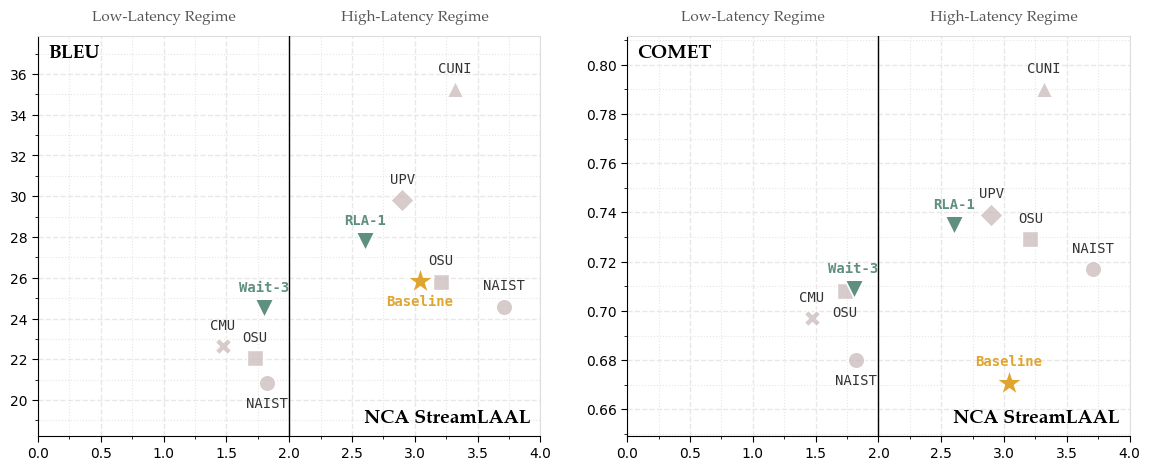

In [4]:
# NOTA: se asume que estas variables ya estan definidas antes en tu script:
#   BASE, COLOR_MAIN, WIDTH_MAIN, COLOR_SUB, WIDTH_SUB, FONT, FONT_SIZE
# y los imports habituales:
#   import pandas as pd
#   import matplotlib.pyplot as plt
#   from matplotlib.ticker import MultipleLocator, AutoMinorLocator

# ── Otros equipos (proceedings) ──────────────────────────────────────────────
csv_path = BASE / "experiments/iwslt_submission/results_procedings.csv"
df = pd.read_csv(csv_path)
df["streamlaal_nca"] = pd.to_numeric(df["streamlaal_nca"], errors="coerce")

# ── Mi submission (desde results_iwslt_submission.csv) ───────────────────────
sub_path = BASE / "experiments/iwslt_submission/results_iwslt_submission.csv"
sub = pd.read_csv(sub_path)
# usar comet_da para que la escala COMET sea consistente con la de los otros equipos
sub = sub.rename(columns={"comet_da": "comet"})
sub["streamlaal_nca"] = pd.to_numeric(sub["streamlaal_nca"], errors="coerce")
sub_by_regime = sub.set_index("regime")

# (regime_en_csv, etiqueta, color, marker, area, offset_etiqueta)
SUBMISSIONS = [
    ("baseline",     "Baseline", "#e0a52e", "*", 420, (0, -20)),
    ("high_latency", "RLA-1",    "#5e8f80", "v", 180, (0,  10)),
    ("low_latency",  "Wait-3",   "#5e8f80", "v", 180, (0,  10)),
]

# ── Estilo por equipo ────────────────────────────────────────────────────────
# Todos los equipos en un mismo rosa claro para que destaquen mis modelos,
# pero con la etiqueta en negro como estaba antes.
TEAM_COLOR       = "#c9b9b9bc"   # rosa claro del marcador de los equipos
TEAM_LABEL_COLOR = "#333333"   # negro de la etiqueta de los equipos

MARKERS = {
    "NAIST": "o", "OSU": "s", "CMU": "X",
    "UPV": "D", "CUNI": "^",
}
AREAS = {  # area del marcador para scatter (puntos^2)
    "NAIST": 140, "OSU": 140, "CMU": 140,
    "UPV": 140, "CUNI": 140,
}

# (columna_y, etiqueta, tick_step, minor_step)
metrics = [
    ("bleu",  "BLEU",  2.0,  1.0),
    ("comet", "COMET", 0.02, 0.01),
]

# estilo base de etiqueta (el color se pasa en cada llamada)
LABEL_KW = dict(fontsize=10, fontfamily="monospace", zorder=5)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))

for ax, (ycol, ylabel, tick_step, minor_step) in zip(axes, metrics):

    ax.set_facecolor("white")
    ax.grid(which="major", color=COLOR_MAIN, linewidth=WIDTH_MAIN, linestyle="--", zorder=0)
    ax.grid(which="minor", color=COLOR_SUB,  linewidth=WIDTH_SUB,  linestyle=":",  zorder=0)
    ax.spines["bottom"].set_color("black")
    ax.spines["left"].set_color("black")
    ax.spines["top"].set_color("#dddddd")
    ax.spines["right"].set_color("#dddddd")
    ax.tick_params(which="major", colors="#000000", length=4, labelsize=10)
    ax.tick_params(which="minor", colors="#000000", length=2, labelsize=0)
    ax.tick_params(top=False, which="both")

    # Todos los equipos (ambos regimenes en el mismo grafico), en rosa claro
    for _, row in df.iterrows():
        team = row["team"]
        ax.scatter(row["streamlaal_nca"], row[ycol],
                   color=TEAM_COLOR,
                   marker=MARKERS.get(team, "o"),
                   s=AREAS.get(team, 140),
                   edgecolors="white", linewidths=1.0, zorder=3)

        # Etiquetas: por defecto encima del punto
        label_off = (0, 10)
        # NAIST Low-Latency siempre por debajo
        if team == "NAIST" and row["regime"] == "Low-Latency":
            label_off = (0, -20)
        # En COMET, OSU: High-Latency por encima, Low-Latency por debajo
        elif ycol == "comet" and team == "OSU":
            label_off = (0, 10) if row["regime"] == "High-Latency" else (0, -20)

        ax.annotate(team, (row["streamlaal_nca"], row[ycol]),
                    textcoords="offset points", xytext=label_off,
                    ha="center", va="bottom", color=TEAM_LABEL_COLOR, **LABEL_KW)

    # Mi submission (baseline + high/low latency) leida del CSV, resaltada
    for regime_key, label, color, marker, area, off in SUBMISSIONS:
        r = sub_by_regime.loc[regime_key]
        # En COMET, Baseline por encima del punto
        if ycol == "comet" and regime_key == "baseline":
            off = (0, 10)
        ax.scatter(r["streamlaal_nca"], r[ycol],
                   color=color, marker=marker, s=area,
                   edgecolors="white", linewidths=1.2, zorder=6)
        ax.annotate(label, (r["streamlaal_nca"], r[ycol]),
                    textcoords="offset points", xytext=off,
                    ha="center", va="bottom",
                    color=color, fontweight="bold", **LABEL_KW)

    # Linea de separacion Low / High en StreamLAAL = 2
    ax.axvline(2, color="black", linewidth=1.0, linestyle="-", zorder=4)

    # Eje X fijo de 0 a 4
    ax.set_xlim(0, 4)

    # Eje Y con margen segun los datos (equipos + mi submission)
    ys = list(df[ycol]) + list(sub[ycol])
    yr = max(ys) - min(ys); pad = yr * 0.18
    ax.set_ylim(min(ys) - pad, max(ys) + pad)

    ax.xaxis.set_major_locator(MultipleLocator(0.5))
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_major_locator(MultipleLocator(tick_step))
    ax.yaxis.set_minor_locator(MultipleLocator(minor_step))

    ax.set_xlabel("")
    ax.set_ylabel("")

    # ── Titulos de eje DENTRO del grafico (esquinas) ─────────────────────────
    ax.text(0.98, 0.02, "NCA StreamLAAL", transform=ax.transAxes,
            fontsize=FONT_SIZE, fontfamily=FONT, fontweight="bold",
            ha="right", va="bottom", color="#000000", zorder=5)
    ax.text(0.02, 0.98, ylabel, transform=ax.transAxes,
            fontsize=FONT_SIZE, fontfamily=FONT, fontweight="bold",
            ha="left", va="top", color="#000000", zorder=5)

    # ── Low / High ARRIBA y FUERA del grid ───────────────────────────────────
    ax.text(0.25, 1.03, "Low-Latency Regime", transform=ax.transAxes,
            fontsize=11, fontfamily=FONT, ha="center", va="bottom",
            color="#555555", zorder=5, clip_on=False)
    ax.text(0.75, 1.03, "High-Latency Regime", transform=ax.transAxes,
            fontsize=11, fontfamily=FONT, ha="center", va="bottom",
            color="#555555", zorder=5, clip_on=False)

fig.patch.set_facecolor("white")
plt.tight_layout(pad=2.5)

out_eps = BASE / "eps/experiments/iwslt25_streamlaal_2panel.eps"
out     = BASE / "experiments/iwslt_submission/iwslt25_streamlaal_2panel"
plt.savefig(out.with_suffix(".png"), dpi=550, bbox_inches="tight", facecolor="white")
plt.savefig(out_eps, bbox_inches="tight", facecolor="white")
plt.show()

# Appendix

## Cascade Wait-k Baseline

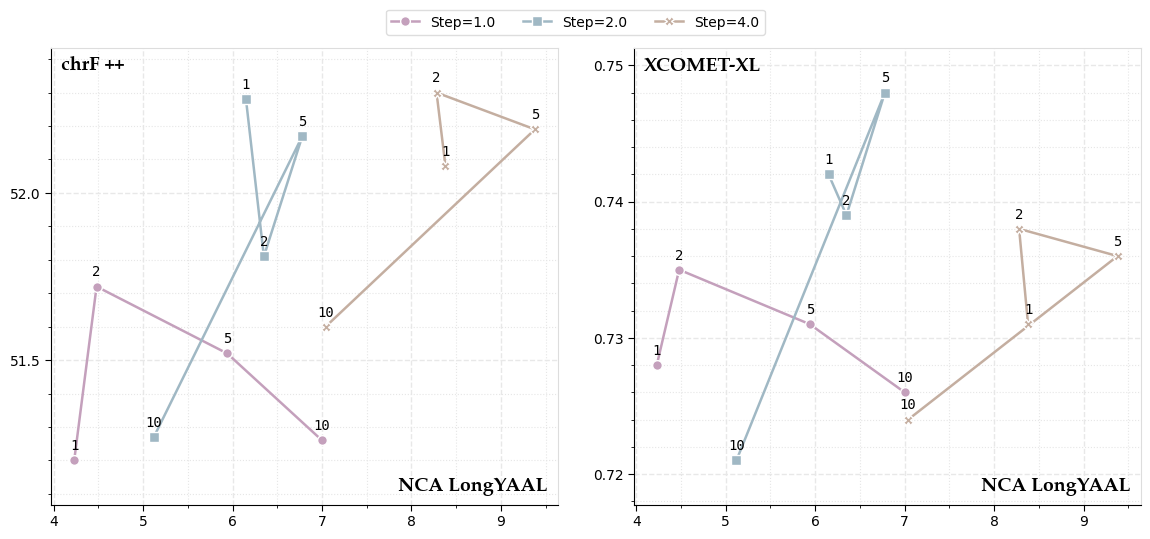

In [21]:
df = pd.read_csv(BASE / "experiments/baselines_trades/cascade/results_cascade.csv")

def parse_name(name):
    parts = name.split("_")
    step = float(parts[1].replace("step", ""))
    la   = int(parts[2].replace("la", ""))
    return step, la

df[["step", "la"]] = df["jsonl_file"].apply(lambda x: pd.Series(parse_name(x)))
df = df[df["step"] < 8]
df = df.sort_values(["step", "la"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

STEP_COLORS = {
    1.0: "#c4a0bc",
    2.0: "#a0b8c4",
    4.0: "#c4aea0",
}

STEP_MARKERS = {
    1.0: "o",
    2.0: "s",
    4.0: "X",
}

configs = [
    ("long_yaal_nca", "NCA LongYAAL", "chrf_pp",  "chrF ++",   0.5,  0.1),
    ("long_yaal_nca", "NCA LongYAAL", "comet_xl", "XCOMET-XL", 0.01, 0.002),
]

MANUAL_ADJUST = {}

MANUAL_ADJUST_COMET = {}

handle_map = {}

for idx, (xcol, xlabel, ycol, ylabel, tick_step, minor_step) in enumerate(configs):
    ax = axes[idx]

    ax.set_facecolor("white")
    ax.grid(which="major", color=COLOR_MAIN, linewidth=WIDTH_MAIN, linestyle="--", zorder=0)
    ax.grid(which="minor", color=COLOR_SUB, linewidth=WIDTH_SUB, linestyle=":", zorder=0)
    ax.spines["bottom"].set_color("black")
    ax.spines["left"].set_color("black")
    ax.spines["top"].set_color("#dddddd")
    ax.spines["right"].set_color("#dddddd")
    ax.tick_params(which="major", colors="#000000", length=4, labelsize=10)
    ax.tick_params(which="minor", colors="#000000", length=2, labelsize=0)
    ax.tick_params(axis="y", colors="#000000")
    ax.tick_params(axis="x", colors="#000000")
    ax.tick_params(top=False, which="both")

    for step, group in df.groupby("step"):
        color  = STEP_COLORS[step]
        marker = STEP_MARKERS[step]
        line, = ax.plot(group[xcol], group[ycol],
                        color=color, linewidth=1.8,
                        marker=marker, markersize=7,
                        markerfacecolor=color,
                        markeredgecolor="white",
                        markeredgewidth=1,
                        zorder=3)
        if idx == 0:
            handle_map[step] = line

    ymin, ymax = df[ycol].min(), df[ycol].max()
    yrange_data = ymax - ymin
    PAD = 0.12
    ax.set_ylim(ymin - yrange_data * PAD, ymax + yrange_data * PAD)

    ax.yaxis.set_major_locator(MultipleLocator(tick_step))
    ax.yaxis.set_minor_locator(MultipleLocator(minor_step))
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))

    offset = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.007

    texts = []
    for step, group in df.groupby("step"):
        for _, row in group.iterrows():
            key = (step, row["la"])
            if key in MANUAL_ADJUST and ycol == "chrf_pp":
                x_off, y_mult = MANUAL_ADJUST[key]
                y_pos = row[ycol] + y_mult * offset
                va = "top" if y_mult < 0 else "bottom"
            elif key in MANUAL_ADJUST_COMET and ycol == "comet_xl":
                x_off, y_mult = MANUAL_ADJUST_COMET[key]
                y_pos = row[ycol] + y_mult * offset
                va = "top" if y_mult < 0 else "bottom"
            else:
                x_off = 0.0
                y_pos = row[ycol] + offset
                va = "bottom"

            t = ax.text(row[xcol] + x_off, y_pos,
                        f"{int(row['la'])}",
                        fontsize=10, color="#000000", fontfamily="monospace",
                        ha="center", va=va)
            texts.append(t)

    adjust_text(texts, ax=ax,
                expand_points=(3, 3),
                expand_text=(3, 3),
                force_text=3, force_points=3,
                only_move={"text": "xy", "points": "xy"})

    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.text(0.98, 0.02, xlabel,
            transform=ax.transAxes,
            fontsize=FONT_SIZE, fontfamily=FONT, fontweight="bold",
            ha="right", va="bottom", color="#000000", zorder=5)

    ax.text(0.02, 0.98, ylabel,
            transform=ax.transAxes,
            fontsize=FONT_SIZE, fontfamily=FONT, fontweight="bold",
            ha="left", va="top", color="#000000", zorder=5)

# ── Leyenda ────────────────────────────────────────────────────────────────
handles       = [handle_map[s] for s in sorted(handle_map)]
legend_labels = [f"Step={s}" for s in sorted(handle_map)]

fig.legend(handles, legend_labels,
           loc="upper center",
           bbox_to_anchor=(0.5, 1.02),
           ncol=3,
           fontsize=10,
           frameon=True,
           framealpha=0.9,
           edgecolor="#dddddd")

fig.patch.set_facecolor("white")
plt.tight_layout(pad=2.5)

out_eps = BASE / "eps/experiments/cascade_plot.eps"
out = BASE / "experiments/baselines_trades/cascade/cascade_plot"
plt.savefig(out.with_suffix(".png"), dpi=550, bbox_inches="tight", facecolor="white")
legend = fig.legends[0]
legend.get_frame().set_alpha(1.0)
plt.savefig(out_eps, bbox_inches="tight", facecolor="white")
plt.show()
